# Water Potability Prediction Using Machine Learning Models
__________________________________________________
### Evaluation, Optimisation and Interpretation of Machine Learning Models for Water Quality Classification

## 1. Introduction

Access to safe drinking water is essential for human health and environmental sustainability.<br> 
Water quality is typically evaluated using several physicochemical parameters such as pH, Hardness, Solids and Turbidity.<br>
Machine learning techniques can be used to analyse these parameters and help predict whether a water sample is potable or not.

## 2. Objective

The objective of this project is to evaluate the performance of different machine learning models to predict whether water is safe for human consumption based on physicochemical water quality parameters.

## 3. Dataset Description

The dataset used in this project comes from the **Water Potability Dataset** available on Kaggle.<br>
Each observation represents a water sample described by several physicochemical parameters related to water quality.

The dataset includes the following variables:
- pH
- Hardness
- Solids
- Chloramines
- Sulfate
- Conductivity
- Organic carbon
- Trihalomethanes
- Turbidity

Target variable:
- **Potability**
   - **1** = Potable (safe for drinking)
   - **0** = Not potable

## 4. Import Libraries 

Python libraries required for data analysis, visualisation and machine learning are imported.<br> 
These libraries provide the functions and tools used throughout the notebook to explore the dataset, process the data and build predictive models.

In [61]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualisation
import matplotlib.pyplot as plt 
import seaborn as sns

# Images
from IPython.display import Image, display
from IPython.display import HTML

# Z-score Method
from scipy.stats import zscore

# Statistical Analysis (Variance Inflation Factor - VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Train-Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Feature Importance (Mutual Information)
from sklearn.feature_selection import mutual_info_classif

# Logistic Regression (LR)
from sklearn.linear_model import LogisticRegression

# K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

# Support Vector Machine (SVM)
from sklearn.svm import SVC

# Gradient Boosting (GB)
from sklearn.ensemble import GradientBoostingClassifier

# Random Forest (RF)
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation Metrics
from sklearn.metrics import accuracy_score            # Accuracy
from sklearn.metrics import classification_report     # Classification Report
from sklearn.metrics import confusion_matrix          # Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay    # Confusion Matrix Visualisation

# ROC Curve and ROC-AUC
from sklearn.metrics import roc_curve, roc_auc_score

# Cross-validation
from sklearn.model_selection import cross_val_score

# Hyperparameter Optimisation
from sklearn.model_selection import GridSearchCV      # Hyperparameter Tuning

import warnings
warnings.filterwarnings("ignore")

## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) provides the first comprehensive understanding of the dataset before data cleaning, preprocessing and machine learning for modelling.<br>
The main objective of this stage is to **explore**, **summarize** and **analyze** the data in order to identify patterns, inconsistencies and potential data quality issues.<br>

In this study, the EDA process includes several key steps:
<br>- **Dataset Introduction**, to examine the structure and general characteristics of the dataset. 
<br>- **Water Quality Parameters**, to describe the meaning and relevance of each variable.
<br>- **Data Structure and Data Types**, to verify data formatting and variable consistency.
<br>- **Descriptive Statistics**,to summarise the main numerical characteristics of the dataset.
<br>- **Distribution Analysis**, to evaluate the spread and behaviour of variable values.
<br>- **Correlation Analysis**, to explore relationships between variables.
<br>- **Skewness Analysis**, to assess distribution symmetry and potential asymmetry.
<br>- **Outlier Detection**, to identify extreme values using **IQR**, **Z-score** and **Percentile-based** methods.

Overall, the findings obtained during the EDA establish the basis for the subsequent **Data Quality Assessment** and **Data Preprocessing** stages, ensuring that the dataset is **well understood and appropriately prepared** for further analysis.

### 5.1 Dataset Introduction

The dataset is loaded and the first rows are displayed to understand its structure.

In [2]:
# Load the dataset
water = pd.read_csv('water_potability.csv')

# Display dataset
water

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


The dataset contains **3,276 water samples** described by physicochemical parameters related to water potability.<br>
Each row represents a different water sample, while each column represents a specific water quality parameter. The column **Potability** is a **binary variable** that indicates whether the water is safe to drink (**1** = potable, **0** = non-potable).<br>
Some variables contain **missing values (NaN)**, which will be analysed and handled later during the **Data Preprocessing** stage.<br>
This dataset does not include spatial or temporal information, meaning that each sample is independent and does not represent a specific geographic location or time period.

### 5.2 Water Quality Parameters

The selected variables **represent key physicochemical characteristics of drinking water** that are commonly used to assess water quality and potability. Together, these parameters provide complementary information for water quality assessment.<br>
The recommended ranges mentioned below are generally based on international drinking-water guidelines, such as the World Health Organization (WHO) Guidelines for Drinking-water Quality and the EU Drinking Water Directive. Values outside these ranges may indicate potential water quality problems and possible risks for human consumption.

**pH**<br>
pH measures the acidity or alkalinity of water and reflects the concentration of hydrogen ions present in the sample.<br>
According to international drinking water guidelines, the recommended range is typically **6.5-8.5**.<br>
Water with a low pH (acidic) may become corrosive, increasing the release of metals from pipes and potentially affecting drinking water quality.<br> 
Water with a high pH (alkaline) may produce an unpleasant taste and promote mineral deposits (scale) in pipes and household appliances.<br>
Extreme pH values, whether acidic or alkaline, may reduce water suitability for human consumption by increasing the risk of metal release, scaling and **irritation to the eyes, skin and mucous membranes**.

**Hardness**<br>
Hardness refers to the concentration of dissolved calcium (Ca²⁺) and magnesium (Mg²⁺) ions in water.<br>
Typical drinking water hardness ranges from **50-150 mg/L**.<br>
Water hardness above 150 mg/l (hard water) can cause scaling in pipes, boilers and household appliances.<br> 
In contrast, water hardness below 50 mg/l (soft water) may increase the corrosion of plumbing systems.<br>
Although hardness generally does not pose a direct health risk, high hardness may reduce water acceptability due to scaling and changes in taste, whereas low hardness may promote **pipe corrosion, increasing the release of metals into drinking water**.

**Solids**<br>
Total dissolved solids (TDS) represent the combined amount of dissolved substances in water, including minerals, salts and trace metals.<br>
Drinking water guidelines generally recommend TDS concentrations **below 500 mg/L**.<br>
High levels of TDS may affect water taste and indicate elevated concentration of dissolved substances or potential contamination from natural or anthropogenic sources.

**Chloramines**<br>
Chloramines are disinfectants formed when chlorine reacts with ammonia during water treatment. They are commonly used to control microbial growth in drinking water distribution systems.<br>
Typical chloramine concentrations are generally **below 4 mg/L**.<br>
Elevated chloramine levels may cause an unpleasant taste and odour and **may irritate the eyes, skin or mucous membranes**. Excessive concentrations may also reduce drinking water acceptability and indicate suboptimal water treatment conditions.

**Sulfate**<br>
Sulfate refers to the concentration of sulfate ions (SO₄²⁻) present in water.<br>
Drinking water guidelines commonly recommend concentrations **below 250 mg/L**.<br>
High sulfate levels may produce a bitter taste and **may have a laxative effect**, particularly for individuals who are not accustomed to such concentrations, potentially limiting its suitability for drinking.

**Conductivity**<br>
Conductivity measures the ability of water to conduct electricity, which depends on the concentration of dissolved ions such as salts and minerals.<br>
Typical drinking water values are usually **below 500 µS/cm**.<br>
High conductivity may indicate elevated concentrations of dissolved ions, suggesting increased mineralization or possible contamination from natural or anthropogenic sources, which may affect the taste and overall quality drinking water.

**Organic Carbon**<br>
Organic carbon represents the amount of organic matter present in water from natural sources or human activities.<br>
Recommended concentrations are generally **below 2 mg/L**.<br>
High organic carbon levels may react with disinfectants during water treatment, forming chemical by-products such as trihalomethanes. Long-term **exposure to these by-products may affect the liver and kidneys** and increase potential health risks.

**Trihalomethanes**<br>
Trihalomethanes (THMs) are chemical by-products formed when chlorine used for water disinfection reacts with natural organic matter.<br>
Recommended concentrations are generally **below 80 µg/L**.<br>
High trihalomethane concentrations have been associated with **potential long-term health risks, including liver and kidney effects and an increased risk of certain cancers** following prolonged exposure.

**Turbidity**<br>
Turbidity measures the cloudiness of water caused by suspended particles such as silt, microorganisms and organic matter.<br>
Drinking water should ideally have turbidity levels **below 1 NTU**.<br>
High turbidity may reduce the effectiveness of disinfection processes and indicate possible microbial contamination, **increasing the risk of gastrointestinal illnesses, including diarrhoea or stomach infections**.

**Potability**<br>
Potability indicates whether the water is considered safe for human consumption.<br>
In this dataset:<br>
    - **1** = potable water  
    - **0** = non-potable water<br>
    
Water is generally considered suitable for drinking when key water-quality parameters fall within recommended guideline values. When one or more parameters exceed these values, the water may require further assessment and may not comply with recommended drinking-water guideliness.

### 5.3 Data Structure and Data Types

An overview of the dataset organisation and the format of its variables is provided. Understanding both the structure and data types is essential to ensure that the dataset is properly prepared for subsequent analysis and modelling.

#### 5.3.1 Data Structure 

The structure of the dataset is examined, including the number of observations and variables, as well as the organisation of the data. This helps understand how the dataset is arranged and whether it is suitable for further analysis.

##### Dataset Shape

In [3]:
# Display dataset shape
water.shape

(3276, 10)

##### Feature Names

In [4]:
# Display feature names
water.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

##### Dataset Information

In [5]:
# Display dataset information
water.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


The function `shape` shows the dimensions of the dataset, indicating the number of rows and columns. In this case, the dataset contains **3,276 rows and 10 columns**.<br>
The function `columns` displays the names of all variables included in the dataset.<br>
Finally, the function `info()` provides a summary of the dataset, including the number of observations, column names, and the number of non-null values for each variable.

#### 5.3.2 Data Types 

The data types of each variable are analysed to ensure that all features are correctly formatted. Verifying data types is important to identify potential inconsistencies and to guarantee compatibility with statistical methods and machine learning algorithms.

In [6]:
# Check data types of each variable
water.dtypes  # astype() is used to change the data type of a single column

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

The output shows the data type associated with each column in the dataset.<br>
**All physicochemical parameters** are numerical continuous variables stored as **floating-point values**, while the target variable **Potability** is stored as an **integer**.<br>
Since the variables are already stored using appropriate data types, no conversion is required. However, if a variable were incorrectly formatted, the function `astype()` could be used to convert it to the appropriate data type.<br>
Additionally, **no non-numeric or inconsistent data types** (such as strings or special characters) **are observed**, confirming that the dataset is clean and properly formatted for further analysis.

### 5.4 Descriptive Statistics 

Descriptive Statistics provide a summary of the main numerical characteristics of the dataset. These measures include central tendency and dispersion, such as the mean, minimum, maximum, and standard deviation for each water quality parameter.

In [7]:
# Generate descriptive statistics
water.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


The Descriptive Statistics summarise the main numerical characteristics of the dataset, including the mean, median (50%), minimum and maximum values, as well as the standard deviation (std) for each water quality parameter.<br>
First, it can be observed that all variables contain non-negative values, which is expected since physicochemical measurements such as **Hardness, Conductivity or Turbidity** cannot be negative. This indicates that there are no obvious data entry errors in the dataset.<br>
For example, the **pH** values range between **0 and 14**, which corresponds to the theoretical scale of pH measurements. This suggests that the pH data fall within physically meaningful limits.<br>
When comparing the mean and median values, some variables such as **Solids** and **Conductivity** show noticeable differences between these two measures. This indicates that their distributions may be slightly skewed rather than perfectly symmetric.<br>
Additionally, the standard deviation values provide information about the dispersion of the data. Parameters such as **Solids** show relatively large standard deviations, suggesting a high variability among the observations.<br>
Overall, the descriptive statistics indicate that the dataset appears consistent and does not contain obvious anomalies that would require immediate correction.

### 5.5 Distribution Analysis

The distribution of each variable is analised to understand how the observations are spread across the dataset. Visual methods are used to identify patterns, skewness and the presence of extreme values.<br>
This analysis provides important insights prior to modelling.

#### 5.5.1 Univariate Distribution Analysis

**Each variable is analysed** individually to understand its distribution. **Histograms** are used to visualise how the values of each parameter are distributed across the dataset, helping identify patterns, skewness, and potential extreme values.

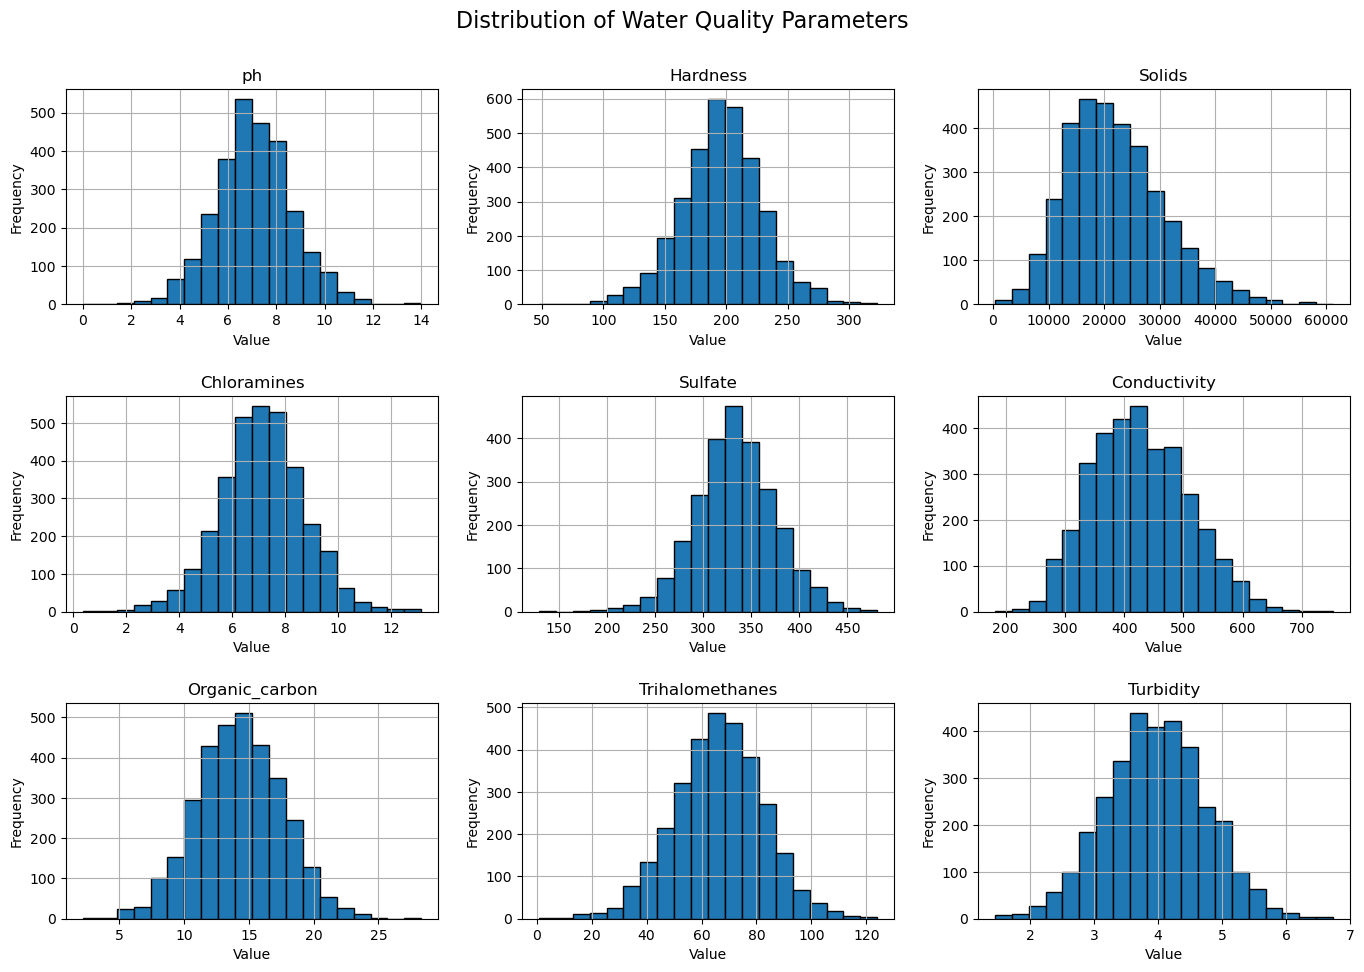

In [8]:
# Separate input features from the target variable
features = water.drop(columns=['Potability'])

# Generate histograms to analise the distribution of each feature
axes = features.hist(figsize=(14,10), bins=20, edgecolor='black')

# Configure axis labels for all subplots
for ax in axes.flatten():
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

# Add an overall title to the figure
plt.suptitle("Distribution of Water Quality Parameters", fontsize=16)

# Adjust spacing between subplots
plt.tight_layout(pad=2)

# Display plots
plt.show()

The **histograms** show that several variables present distributions that are approximately symmetric, with values concentrated around the central range of the data.<br>
However, some parameters such as **Solids** and **Conductivity** show slightly right-skewed distributions, where most observations are concentrated at lower values while fewer observations extend toward higher values.<br>
Other variables such as **pH**, **Hardness**, and **Chloramines** appear more symmetrically distributed around their central values.<br>
These patterns suggest that while most variables behave relatively consistently, some features may exhibit mild skewness, which will be examined further using skewness statistics in subsequent sections.

#### 5.5.2 Bivariate Distribution Analysis

The distribution of **variables in relation to the target variable (Potability)** is analysed to identify patterns, differences between classes and potential relationships that may be relevant for predictive modelling.

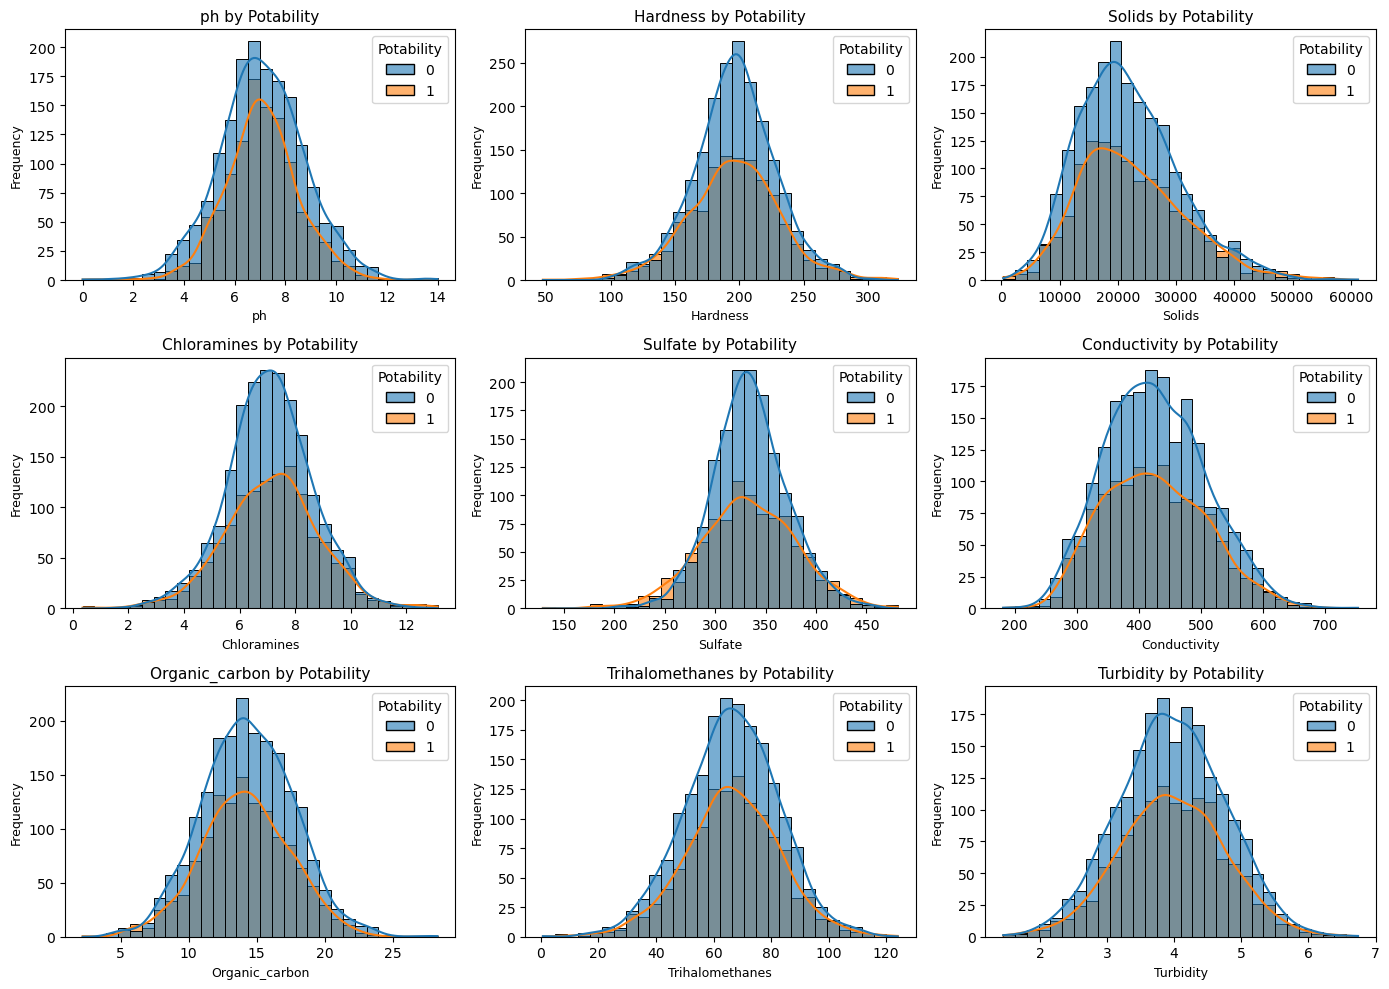

In [9]:
# Analyse feature distributions by target variable (Potability)

# Create figure and define layout
plt.figure(figsize=(14,10))

# Plot histograms for each feature grouped by Potability
for i, column in enumerate(features.columns, 1):
    plt.subplot(3, 3, i)    
    sns.histplot(data=water, x=column, hue='Potability', kde=True, bins=30, alpha=0.6 )    
    
    # Configure plot titles and axis labels
    plt.title(f'{column} by Potability', fontsize=11)
    plt.xlabel(column, fontsize=9)
    plt.ylabel('Frequency', fontsize=9)

# Adjust layout and display plots
plt.tight_layout()
plt.show()

The **degree of overlap** between the distributions is a key factor in determining whether a variable can effectively distinguish between potable and non-potable water.<br>
A **strong overlap** occurs when both classes share a similar range of values along the horizontal axis, meaning that the same values are observed for both potable and non-potable samples. In such cases, the variable does not provide clear separation and is not sufficient for classification on its own.<br>
In contrast, a **weak overlap** occurs when the distributions are more separated, with each class occupying a different range of values. In this scenario, the variable can better distinguish between potable and non-potable water, making it more useful for predictive purposes.<br>
In this analysis, most variables show a **strong overlap**, indicating that they do not individually provide strong discriminatory power.<br>
It is also important to note that differences in the **height of the distributions** reflect differences in frequency rather than separation. Higher peaks indicate a greater number of observations for a given class. In this case, the higher peaks observed for non-potable water suggest the presence of a **class imbalance**, where one class contains more observations than the other.<br>
These findings indicate that individual variables alone are insufficient to accurately classify water potability. Therefore, it is necessary to consider **multiple variables simultaneously** to capture more complex relationships within the dataset.<br>
In practice, this involves using **machine learning models**, which can combine information from several features to improve predictive performance and  achieve more robust classification results.

### 5.6 Skewness Analysis

To complement the visual interpretation of the distributions, skewness is calculated for each numerical variable.

Skewness measures the degree of asymmetry in a distribution.
- Values **close to 0** indicate approximately **symmetric distribution**.
- **Positive** values indicate a **right-skewed** distribution (long tail to the right).
- **Negative** values indicate a **left-skewed** distributions (long tail to the left).

This analysis provides a quantitative assesssment of distribution shape, supporting the observations made from histograms. 

In [10]:
# Create an empty list to store skewness results
skewness_summary = []

# Loop through each column
for col in features.columns:
    data = features[col].dropna()  # Missing values are temporarily excluded from the analysis to ensure accurate statistical calculations
    skew_value = round(data.skew(), 3)
    # Restore results
    skewness_summary.append([col, skew_value])

# Convert list to DataFrame
skewness_table = pd.DataFrame(skewness_summary, columns=['Parameter', 'Skewness'])   

# Display table without index
skewness_table.style.hide(axis='index').format({'Skewness': '{:.3f}'})

Parameter,Skewness
ph,0.026
Hardness,-0.039
Solids,0.622
Chloramines,-0.012
Sulfate,-0.036
Conductivity,0.264
Organic_carbon,0.026
Trihalomethanes,-0.083
Turbidity,-0.008


The interpretation of skewness values can be summarised as follows:

| Skewness value | Interpretation |
|----------------|---------------|
| -0.5 to 0.5 | Approximately symmetric distribution |
| 0.5 to 1 or -0.5 to -1 | Moderately skewed distribution |
| > 1 or < -1 | Highly skewed distribution (possible candidate for transformation) |

The skewness results indicate that most variables are approximately symmetric.<br>
Some variables, particularly **Solids** and **Conductivity**, show moderate positive skewness, suggesting a slight **right-skewed** distributions.<br>
However, the magnitude of skewness across the variables is not extreme, indicating that the dataset does not exhibit strong asymmetry.

### 5.7 Correlation Analysis

Correlation Analysis examines the relationships between numerical variables in the dataset to determine how they change in relation to one another.<br>
It measures the strength and direction of the linear association between pairs of variables using correlation coefficients, which range from -1 to 1.
- A value **close to 1** indicates a **strong positive relationship**, meaning both variables tend to increase together.
- A value **close to -1** indicates a **strong negative relationship**, where one variable increases while the other decreases.
- A value **near 0** suggests little to **no linear relationship** between variables.

This analysis allows the identification of potential dependencies, redundant features and interactions between variables before applying machine learning models.

In [11]:
# Compute correlation matrix including target
corr_matrix = water.corr()

# Display correlaton matrix
corr_matrix

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.082096,-0.089288,-0.034350,0.018203,0.018614,0.043503,0.003354,-0.039057,-0.003556
Hardness,0.082096,1.000000,-0.046899,-0.030054,-0.106923,-0.023915,0.003610,-0.013013,-0.014449,-0.013837
Solids,-0.089288,-0.046899,1.000000,-0.070148,-0.171804,0.013831,0.010242,-0.009143,0.019546,0.033743
Chloramines,-0.034350,-0.030054,-0.070148,1.000000,0.027244,-0.020486,-0.012653,0.017084,0.002363,0.023779
Sulfate,0.018203,-0.106923,-0.171804,0.027244,1.000000,-0.016121,0.030831,-0.030274,-0.011187,-0.023577
Conductivity,0.018614,-0.023915,0.013831,-0.020486,-0.016121,1.000000,0.020966,0.001285,0.005798,-0.008128
Organic_carbon,0.043503,0.003610,0.010242,-0.012653,0.030831,0.020966,1.000000,-0.013274,-0.027308,-0.030001
Trihalomethanes,0.003354,-0.013013,-0.009143,0.017084,-0.030274,0.001285,-0.013274,1.000000,-0.022145,0.007130
Turbidity,-0.039057,-0.014449,0.019546,0.002363,-0.011187,0.005798,-0.027308,-0.022145,1.000000,0.001581
Potability,-0.003556,-0.013837,0.033743,0.023779,-0.023577,-0.008128,-0.030001,0.007130,0.001581,1.000000


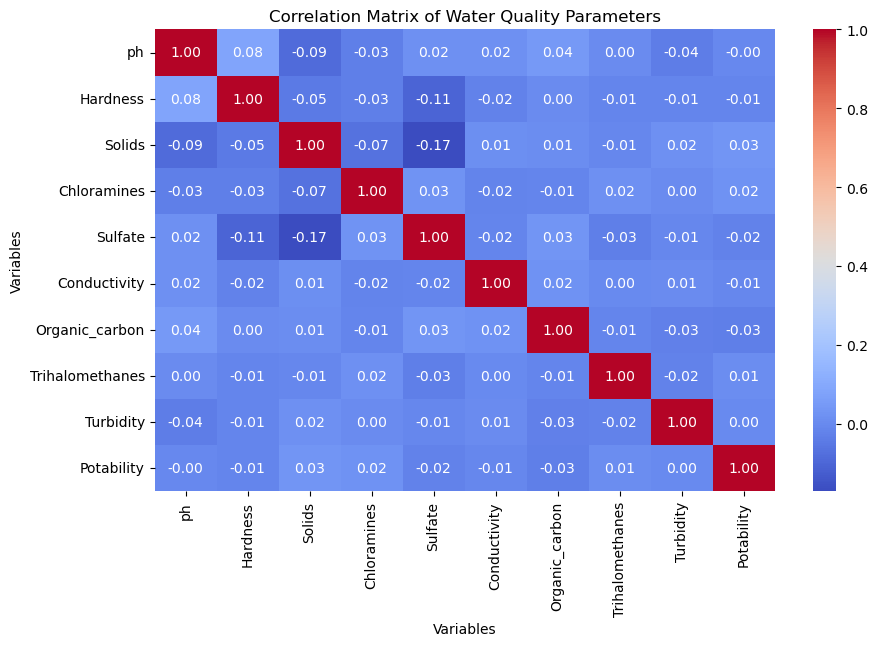

In [12]:
# Create correlation matrix for numerical variables
correlation_matrix = water.corr()

# Set figure size
plt.figure(figsize=(10, 6))

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

# Add title and labels
plt.title('Correlation Matrix of Water Quality Parameters')
plt.xlabel('Variables')
plt.ylabel('Variables')

# Display plot
plt.show()

The interpretation of correlation coefficients can be summarised as follows:

| Correlation value | Interpretation |
|------------------------|----------------|
| 0.0 – ±0.3 | Very weak or no correlation |
| ±0.3 – ±0.5 | Weak correlation |
| ±0.5 – ±0.8 | Moderate correlation |
| ±0.8 – ±1.0 | Strong correlation (potential multicollinearity) |

The **Correlation Matrix of Water Quality Parameters** shows that most variables exhibit **very weak linear relationships**, with correlation coefficients close to zero. This indicates that water quality parameters largely vary independently from one another.<br>
No strong positive or negative correlations (values close to ±1) are observed, suggesting the **absence of strong linear dependencies** within the dataset. Consequently, **the risk of multicollinearity is low**, meaning that the features are not redundant and may contribute unique information to the model.<br>
In relation to the target variable (**Potability**), all correlations remain weak, indicating that **no single variable has a strong linear relationship** with water potability.<br>
Overall, these findings suggest that water potability cannot be explained by a single parameter alone, but rather by a **combination of multiple variables**, supporting the use of **multivariate machine learning models**.

### 5.8 Scatter Plot Analysis  

Scatter plots are used to examine the relationship between two variables by displaying individual data points in a two-dimensional space. This allows the visualization of patterns such as trends, dispersion and potential separation between classes.<br>
When a target variable is included (e.g., Potability), different colors can be used to distinguish between classes, helping assess whether the data points form distinct groups or overlap.<br>
A pairplot extends this analysis by showing scatter plots. 

#### 5.8.1 Scatterplot

A representative scatter plot is generated to examine the relationship between two selected variables (Turbidity and Sulfate) and their association with the target variable (Potability).<br>
This visualisation also helps identify potential patterns, clustering behavior and possible linear or non-linear relationships between variables.

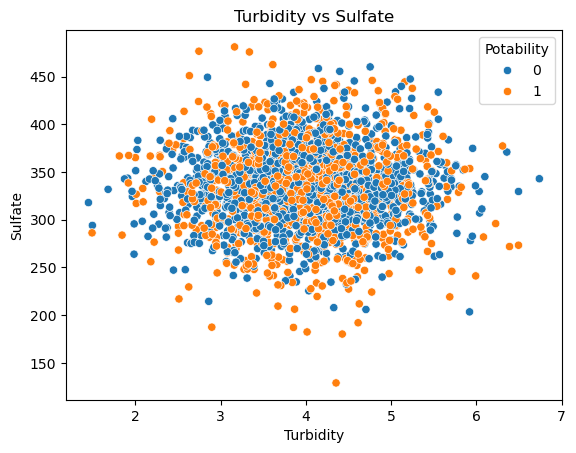

In [13]:
# Generate scatter plot
sns.scatterplot(data=water, x='Turbidity', y='Sulfate', hue='Potability')

# Set tables and labels
plt.title('Turbidity vs Sulfate')
plt.xlabel('Turbidity')
plt.ylabel('Sulfate')

# Display plot
plt.show()

The scatter plot of Turbidity vs Sulfate shows a **strong overlap** between potable and non-potable samples, where observations from both classes are highly intermixed. No clear linear separation or clustering pattern is observed between classes, suggesting that these variables alone may not sufficiently differentiate water potability.

#### 5.8.2 Pairplot

A pairplot is used to visualize the relationships between all variables simultaneously by combinig multiple scatter and distributions plots in a single matrix. This allows the exploration of how feature combinations are distributed 
and how they relate to the target variable (Potability).<br>

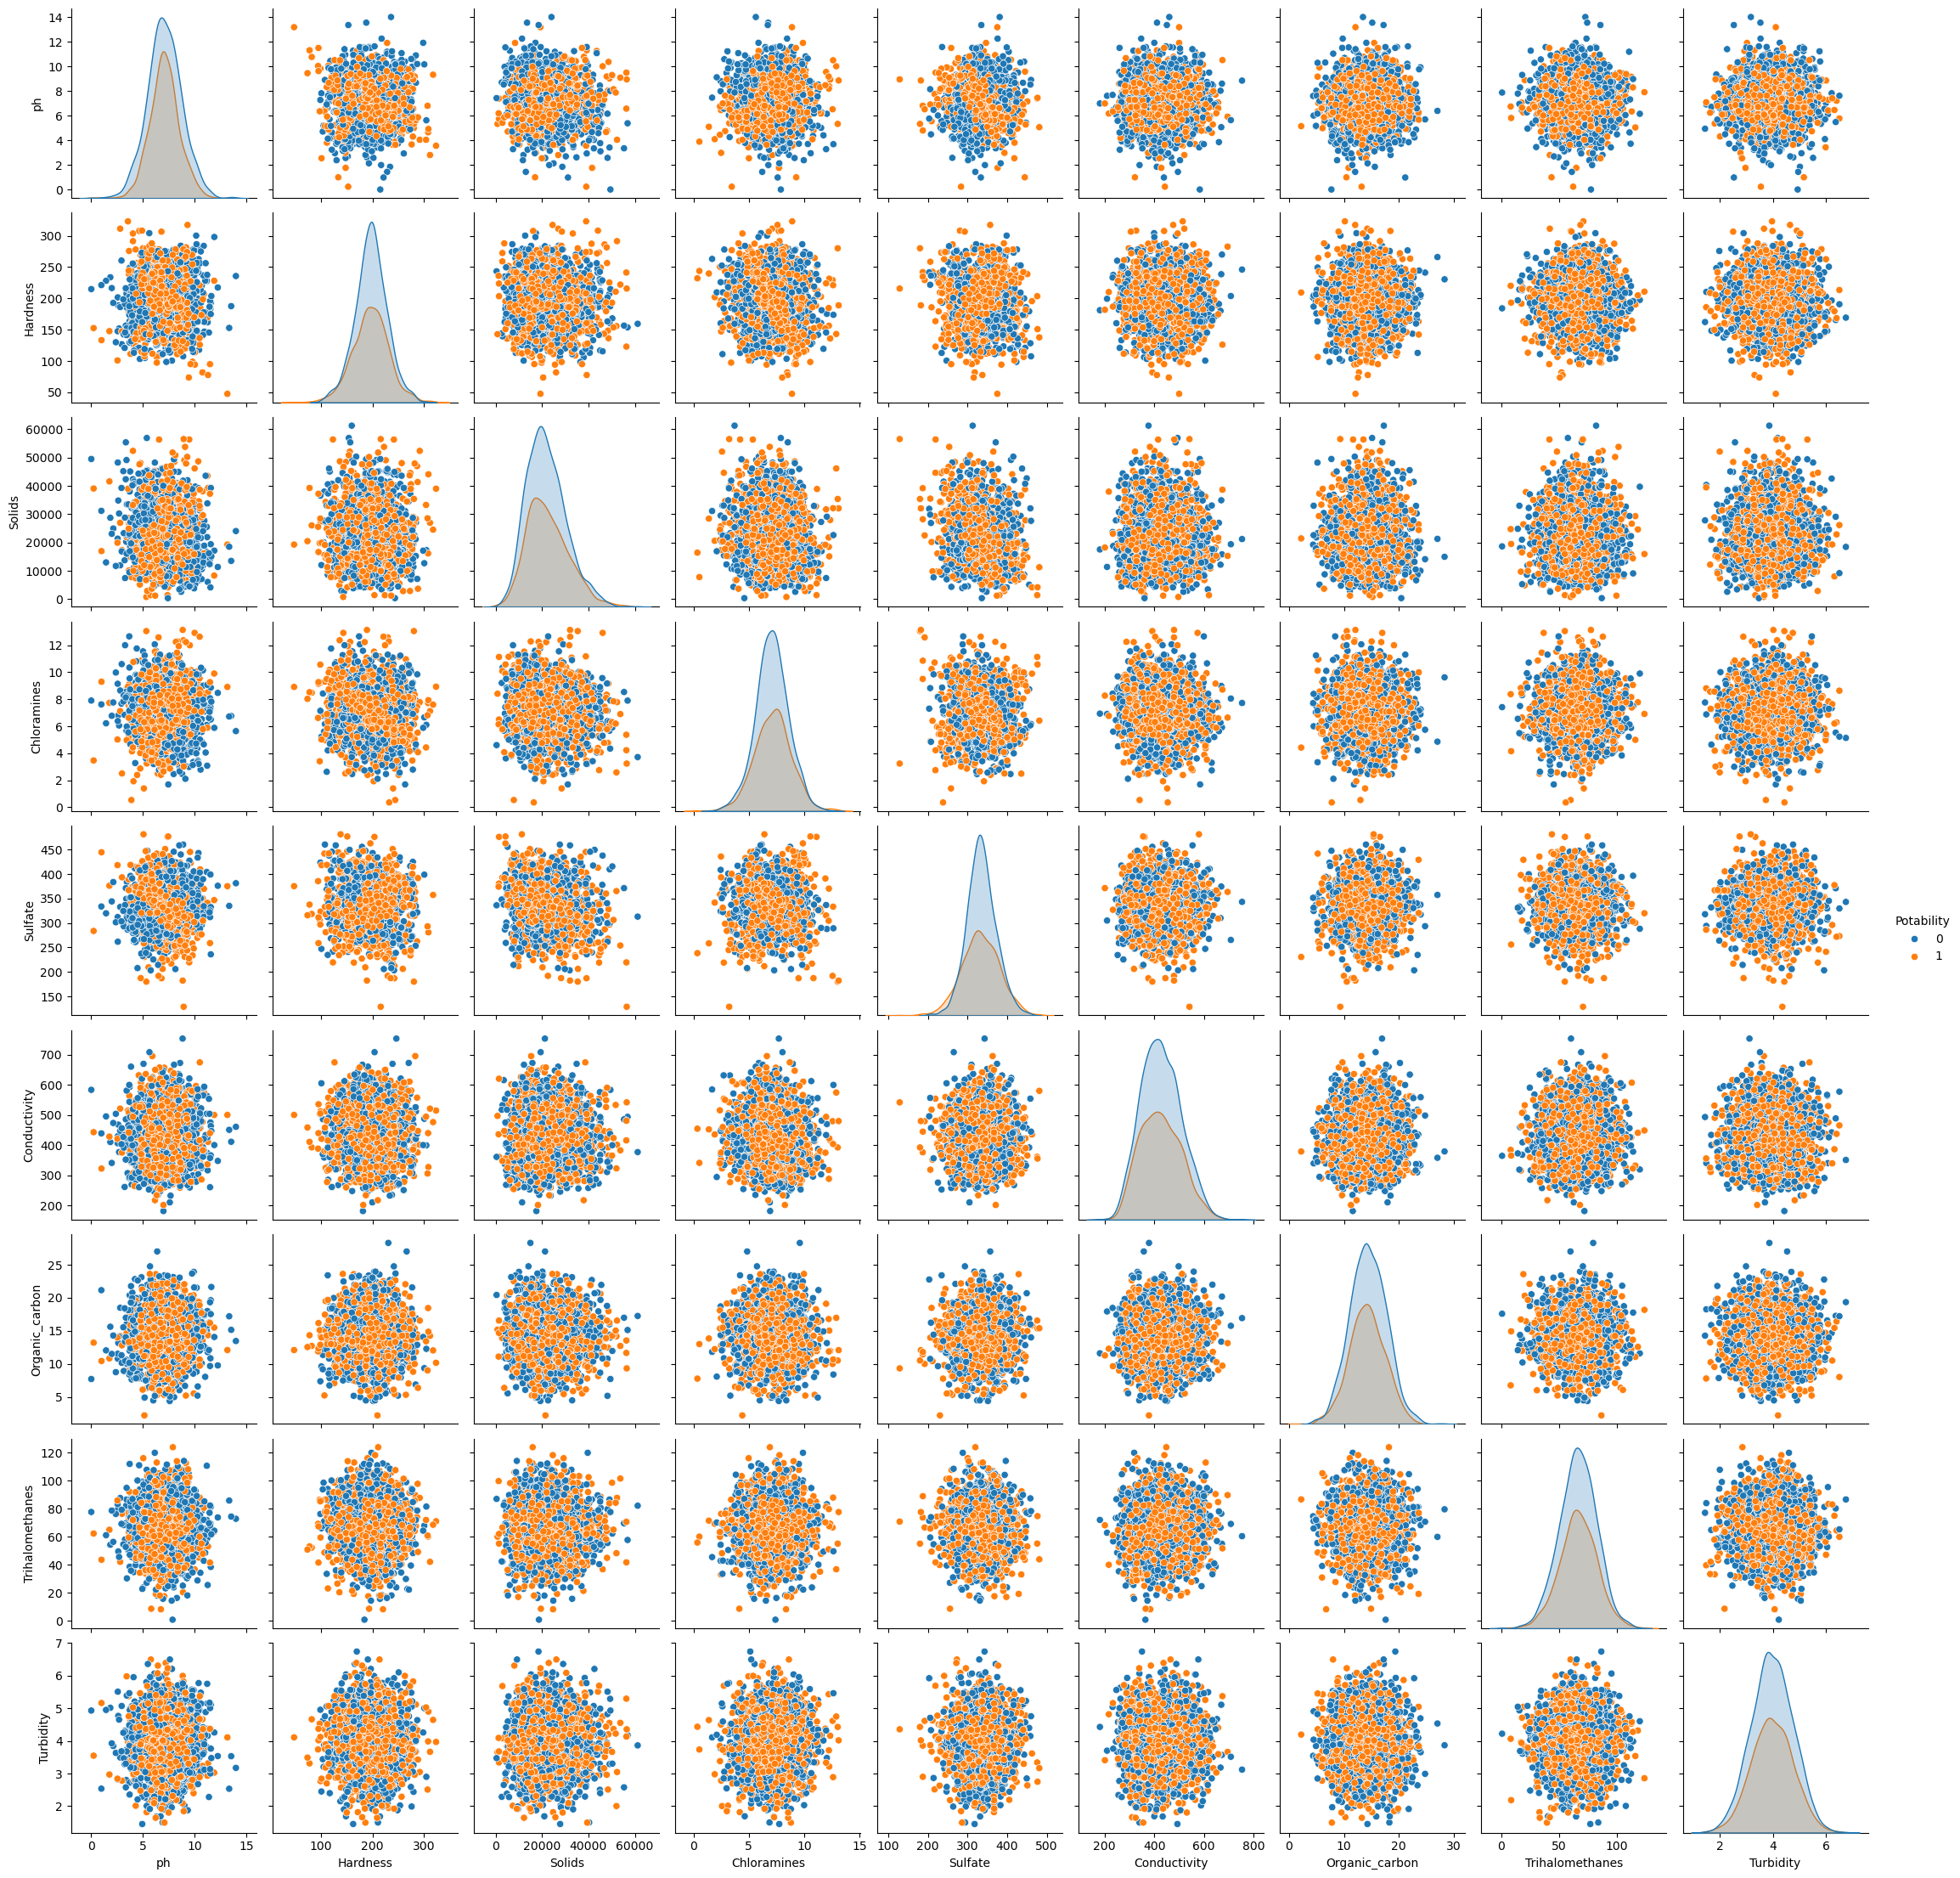

In [14]:
# Generate pairplot
sns.pairplot(water, hue='Potability', diag_kind='kde')

# Display plot
plt.show()

The pairplot confirms a **strong overlap** across multiple feature combinations, showing no clear linear separation or distinct clustering patterns between potable and non-potable classes. This suggests that water potability classification depends on the combined interaction of multiple variables rather than on a single feature independently.

### 5.9 Outlier Detection

Outliers are observations that differ significantly from the majority of the data.<br> 
Detecting potential outliers is an important step in exploratory data analysis, as extreme values may influence statistical summaries and machine learning models.<br>
In this study, boxplots are used as a visual tool to identify potential outliers in the water quality parameters.<br> 
It is important to note that, at this stage, outliers are only **identified and analysed**, while decisions regarding their treatment are addressed later during the **Data Preprocessing** stage. 

#### 5.9.1 Overview Boxplot Analysis

Boxplots are used to visually identify potential outliers in the dataset.<br> 
They summarise the distribution of each variable by displaying the **median**, **interquantile range (IQR)** and extreme values.<br> 
Observations that fall outside the whiskers may indicate potential outliers. The whiskers typically extend to 1.5 times the IQR bellow the first quartile (Q1) and above the third quartile (Q3).

The following diagram illustrates the main components of a boxplot:

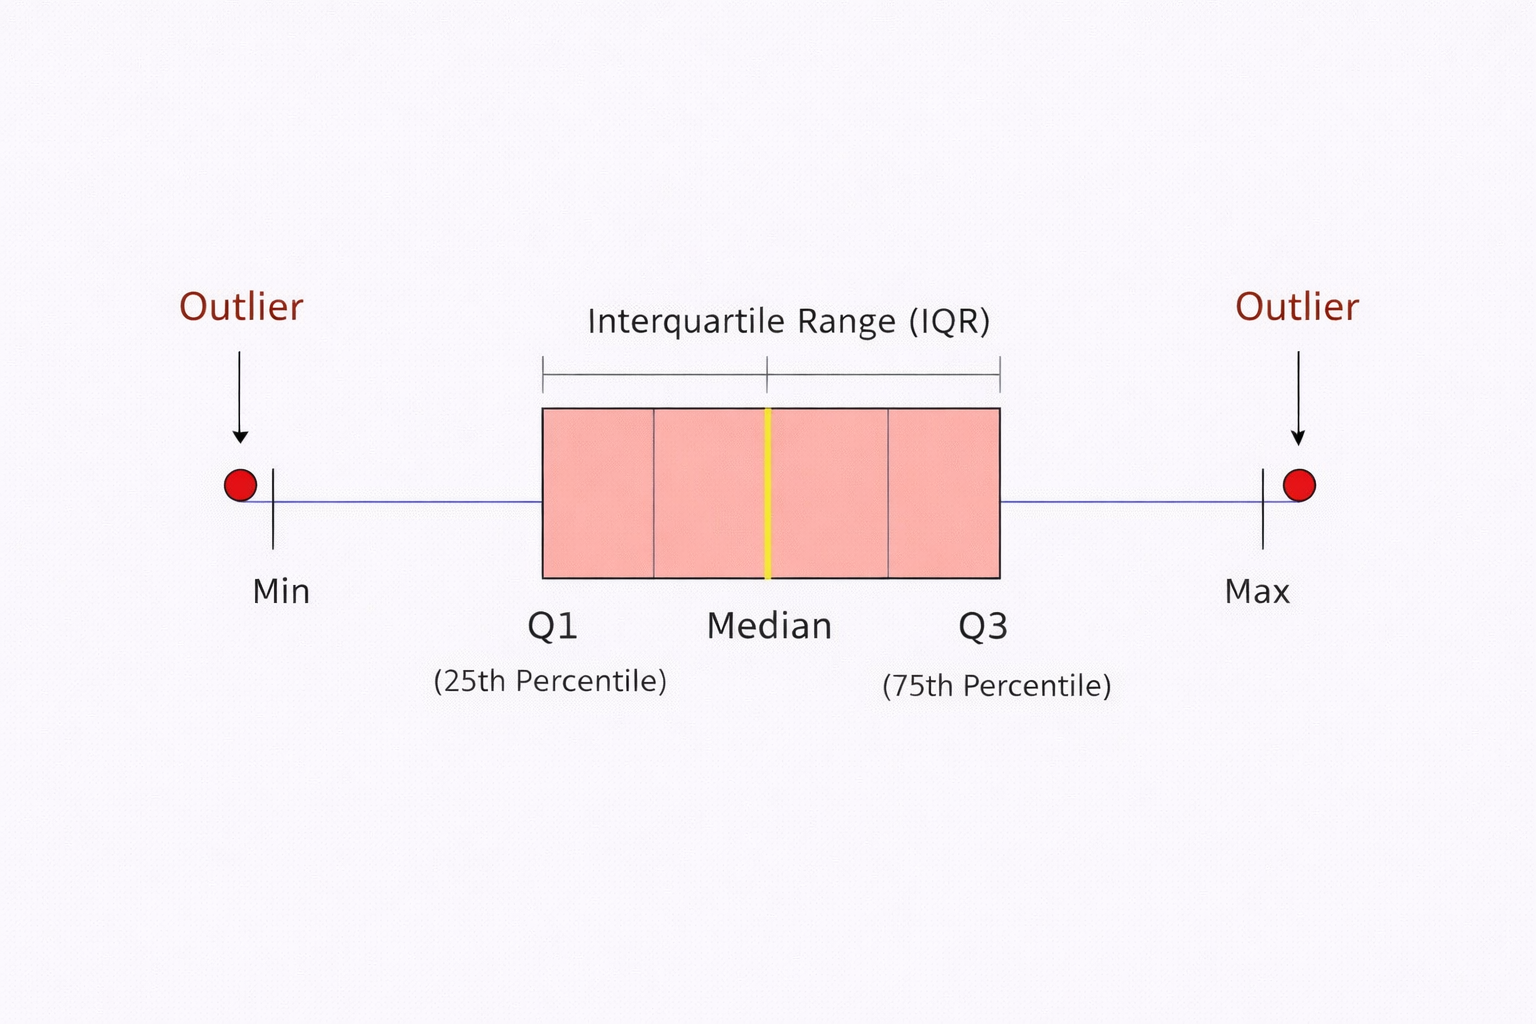

In [15]:
from IPython.display import Image, display
display(Image(filename='boxplot_components.png', width=600))

The Interquartile Range (IQR) method is used to identify potential outliers based on the spread of the data.

| Component        | Formula |
|------------------|---------|
| **IQR**          | Q3 - Q1 |
| **Lower Bound**  | Q1 - 1.5 × IQR |
| **Upper Bound**  | Q3 + 1.5 × IQR |

Outliers are defined as observations that fall outside this expected range.

- Values below the **lower bound** are considered lower outliers  
- Values above the **upper bound** are considered upper outliers

These limits define the typical spread of the data and any observations beyond them are considered potential outliers.

In a boxplot: 
<br>- The box represents the **interquartile range (IQR)**, which contains the middle 50% of the data
<br>- The line inside the box represents the **median**
<br>- The whiskers extend to the minimum and maximum values within the accepted range<
<br>- Values outside this range are considered **outliers**

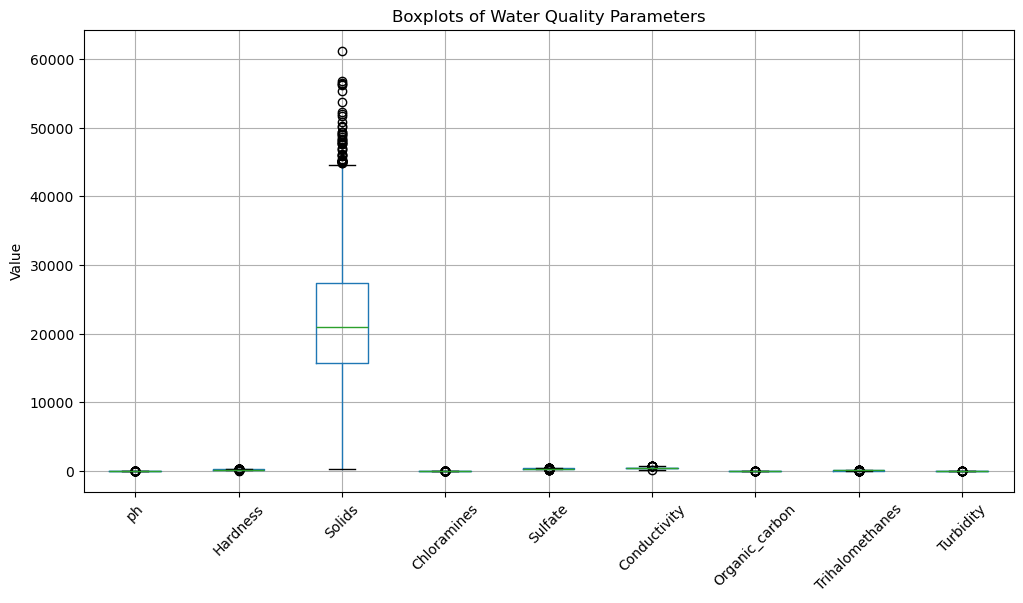

In [16]:
# Create boxplots for all variables and rotate x-axis labels
plt.figure(figsize=(12,6))
features.boxplot(rot=45)

# Add title and axis label
plt.title("Boxplots of Water Quality Parameters")
plt.ylabel("Value")

# Display the plot
plt.show()

The boxplot shows that several variables present values that extend beyond the typical range, indicating the presence of potential outliers.<br>
In particular, variables such as **Solids** exhibit a much wider range compared to other parameters, with numerous extreme values. This large variation affects the visualisation, making it difficult to clearly observe the distribution of variables with smaller scales.<br>
To obtain a more detailed understanding of outliers across individual features, separate boxplots are analysed in the following section.

#### 5.9.2 Univariate Boxplot Analysis

To improve the visualisation, boxplot are generated separately for each variable.<br>
This allows for a clearer observation of the distribution and potential outliers without the influence of the scale differences across variables.

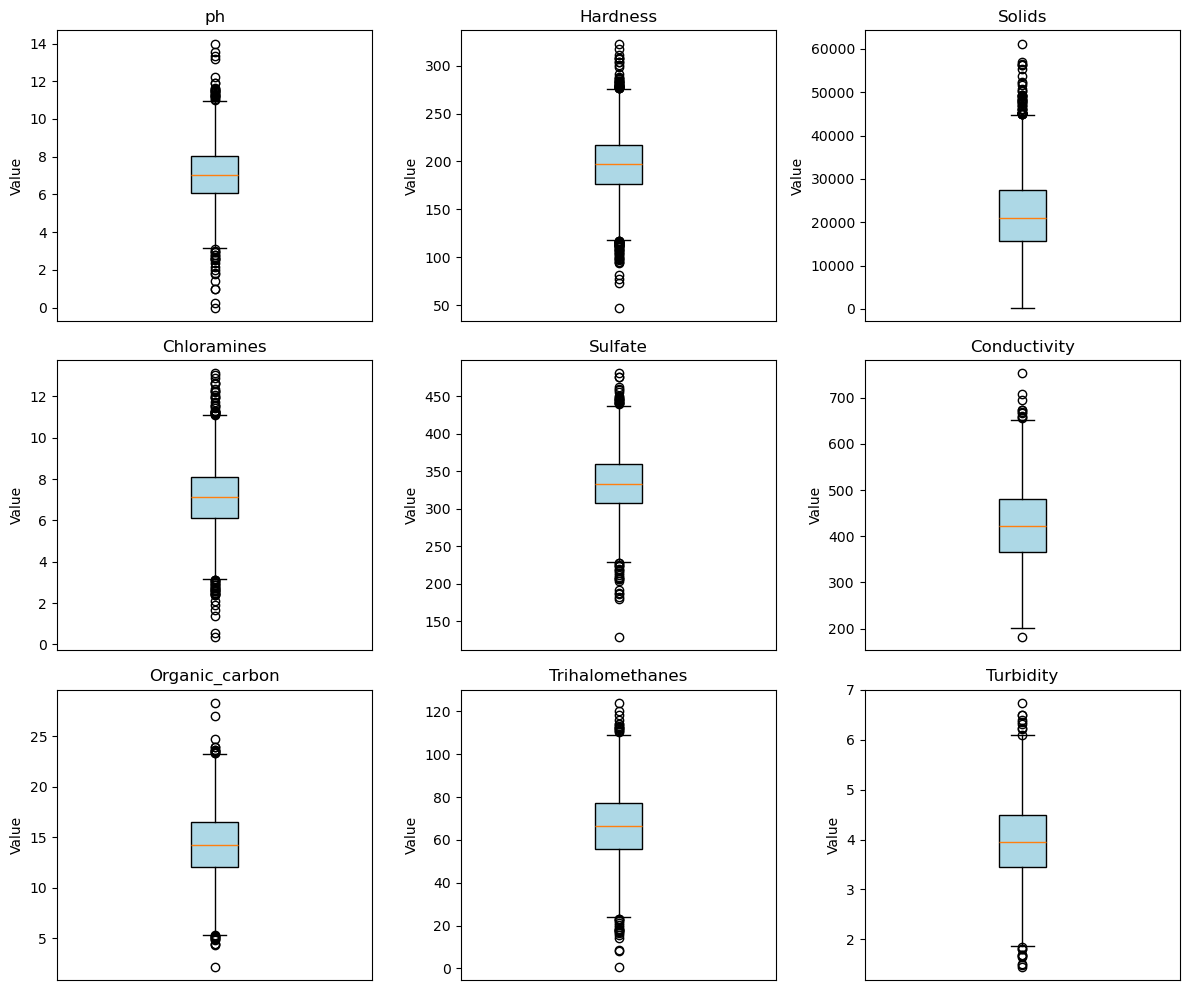

In [17]:
# Generate boxplots for each variable in a grid layout (3x3)

# Create boxplots in a grid layout
plt.figure(figsize=(12,10))

# Loop through each feaature to create individual boxplots 
for i, col in enumerate(features.columns, 1):
    plt.subplot(3,3,i)
    plt.boxplot(features[col].dropna(), patch_artist=True, boxprops=dict(facecolor='lightblue'))
    
    # Add titles and labels
    plt.title(col)
    plt.ylabel("Value")

    # Remove '1' on x-axis
    plt.gca().set_xticks([])

# Adjust spacing between plots
plt.tight_layout()
plt.show()

The boxplots reveal the presence of outliers across most variables.<br>
This pattern is common in environmental datasets, where natural variability leads to fluctuations in water quality parameters.<br> 
Therefore, these values are not immediately considered errors, but will be further evaluated during the **Data Preprocessing** stage to determine whether they should be retained, transformed or removed.

#### 5.9.3 IQR Method

The IQR Method is used to identify outliers by measuring the spread of the central portion of the data. This method focuses on the range between the first quartile **(Q1)** and the third quartile **(Q3)**, which represents the middle 50% of the dataset.<br>
**Outliers** are defined as values that fall outside the **lower and upper limits** derived from this range, which are visualised as the whiskers in a boxplot.<br>
Unlike the Z-score method, the IQR approach does not rely on the mean or standard deviation, but instead is based on the **median and quartiles**. This maks it more robust and less sensitive to extreme values.<br> 
This method is particularly useful for **skewed distributions**, where extreme values may affect other statistical approaches.<br> 
In this case, although most variables show relatively low skewness and symmetric distributions, the IQR method is used as a complementary approach to compare results with other techniques.

In [18]:
# Identify outliers using IQR method for each variable

# Create an empty list to store outliers count
iqr_summary = []

# Loop through each feature column
for col in features.columns:
    data = features[col].dropna()  # Missing values are temporarily excluded from the analysis to ensure accurate statistical calculations    
    # Calculate IRQ
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3-Q1
    # Min and Max values 
    lower = Q1-1.5*IQR 
    upper = Q3+1.5*IQR 
    # Identify outliers
    outliers = data[(data < lower) | (data > upper)]
    # Store results
    iqr_summary.append([col, len(outliers)])

# Convert list to DataFrame
iqr_table = pd.DataFrame(iqr_summary, columns=['Parameter', 'Outliers'])   

# Display table without index
iqr_table.style.hide(axis='index')

Parameter,Outliers
ph,46
Hardness,83
Solids,47
Chloramines,61
Sulfate,41
Conductivity,11
Organic_carbon,25
Trihalomethanes,33
Turbidity,19


The **IQR results** show that outliers are present across all variables, although their frequency varies.<br>
Variables such as **Hardness** and **Chloramines** exhibit a higher number of outliers, indicating greater variability in their values. In contrast, parameters like **Conductivity** and **Turbidity** present fewer extreme values.<br>
These variations suggest that some water quality parameters are more sensitive to fluctuations than others, possibly due to differences in chemical composition or environmental influence.<br>
Overall, the presence of outliers is expected in environmental datasets, where natural variability and external factors can significantly influence measurements.<br>
Since the **IQR** method is based on the **median and quartiles**, it is more robust to extreme values, which explains its ability to detect a relatively higher number of outliers.<br> 
These results will be further compared with the Z-score and Percentile-based methods to evaluate differences in outlier detection.

#### 5.9.4 Z-score Method 

The Z-score Method is used to identify outliers by measuring how far each value is from the **mean** in terms of **standard deviations**.<br>
This approach standardizes the data so that the **mean becomes 0** and the **standard deviation becomes 1**, allowing values to be compared on the same scale.<br>
Values with a **Z-score greater than +3 or less than -3** are typically considered outliers.<br>
Unlike the IQR method, the Z-score approach relies on the **mean and standard deviation**, which makes it sensitive to extreme values. As a result, the presence of outliers can influence these statistics and potentially reduce the ability of the method to detect all extreme observations.<br>
This method is most appropriate for approximately **normal or symmetric distribution**.<br> 
In this case, since most variables show relatively low skewness and near-symmetric distributions, the Z-score method is considered suitable.<br>
However, for highly skewed variables, other methods such as the IQR or Percentile-based methods may be more reliable.

In [19]:
# Identify outliers using Z-score method for each variable

# Create an empty list to store outliers count
zscore_summary = []

# Loop through each feature column
for col in features.columns:  
    data = features[col].dropna()  # Missing values are temporarily excluded from the analysis to ensure accurate statistical calculations
    z_scores = zscore(data)    
    # Identify outliers (|z| > 3)
    outliers = data[(z_scores > 3) | (z_scores < -3)]    
    # Store results    
    zscore_summary.append([col, len(outliers)])

# Convert list to DataFrame
zscore_table = pd.DataFrame(zscore_summary, columns=['Parameter', 'Outliers'])

# Display table without index
zscore_table.style.hide(axis='index')

Parameter,Outliers
ph,16
Hardness,18
Solids,20
Chloramines,20
Sulfate,17
Conductivity,7
Organic_carbon,4
Trihalomethanes,12
Turbidity,9


The **Z-score results** show a lower number of detected outliers compared to the **IQR** method.<br>
Most variables present relatively few extreme values, indicating that the majority of the data is concentrated around the **mean**.
Paramaters such as **Solids**, **Chloramines** and **Hardness**, which showed a high number of outliers using the **IQR** method, still present the highest number of outliers in this approach, although at a reduce level.<br>
These differences suggest that the **Z-score** method is more restrictive in detecting outliers, as it depends on the **mean and standard deviation**, which can be influenced by extreme values.<br>
Overall, these results confirm that the choice of method can significantly influence the identification of outliers in the dataset.

#### 5.9.5 Percentile-based Method 

The Percentile-based Method is used to identify outliers by defining thresholds based on fixed percentiles, such as the **1st percentile (P1)** and the **99th percentile (P99)**.<br>
Values that fall below **P1** or above **P99** are considered extreme and may be classified as outliers.<br>
Unlike the IQR and Z-score methods, this approach does not rely on the **mean**, **median**, or **standard deviation**, but instead uses the relative position of values within the dataset.<br>
This method does not assume any specific data distribution and is useful for **skewed distributions** or datasets with irregular patterns.<br>
However, since the thresholds are fixed, the method may be sensitive to the choice of percentiles and may either overestimate or underestimate the number of outliers depending on the data.<br>
In this study, the Percentile-based Method is applied as an additional reference to compare results with the **IQR and Z-score** methods.

In [20]:
# Create an empty list to store outliers count
percentile_summary = []

# Loop through each feature column
for col in features.columns:   
    # Drop missing values
    data = features[col].dropna()    
    # Calculate percentiles
    lower_bound = data.quantile(0.01)   # P1
    upper_bound = data.quantile(0.99)   # P99   
    # Identify outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]    
    # Count outliers
    outlier_count = len(outliers)   
    # Append results
    percentile_summary.append([col, outlier_count])

# Convert list to DataFrame
percentile_table = pd.DataFrame(percentile_summary, columns=['Parameter', 'Outliers'])

# Display table without index
percentile_table.style.hide(axis='index').format({'Outliers': "{:.0f}"})

Parameter,Outliers
ph,56
Hardness,66
Solids,66
Chloramines,66
Sulfate,50
Conductivity,66
Organic_carbon,66
Trihalomethanes,64
Turbidity,66


The **Percentile-based results** detect a higher number of outliers across most variables. Several parameters, such as **Hardness**, **Solids**, **Chloramines**, **Conductivity**, **Organic Carbon**, and **Turbidity**, show similar outlier counts, indicating the presence of extreme values in multiple variables.<br>
Compared to the **Z-score** method, this approach identifies more outliers, as it does not rely on the **mean** or **standard deviation**, but instead uses fixed **percentiles** to define thresholds.<br>
This explains why the method is more sensitive in detecting extreme values, since any observation falling outside the selected percentile range is automatically considered an outlier.<br>
However, this approach may also include values that are not necessarily abnormal, but part of the natural variability of the dataset.

#### 5.9.6 Comparison of Outliers Detection Methods

Outliers were identified using three different approaches: **IQR**, **Z-score** and **Percentile-based** methods.<br>
The **IQR** method detected the highest number of outliers across most variables. This is because it is based on the **median** and is more robust to variability, making it suitable for environmental datasets.<br>
The **Z-score** method identified fewer outliers, as it relies on the **mean and standard deviation**, making it more sensitive to extreme values and more appropriate for approximately **normal distributions**.<br>
The **Percentile-based** method also detected a relatively high number of outliers, as it uses fixed thresholds. However, this method may include values that are part of the natural variability of the dataset.<br>
Considering that most variables show relatively **low skewness and near-symmetric distributions**, the **Z-score** method is selected as the preferred approach for this study.<br>
The **IQR and Percentile-based** methods are used as complementary references to better understand data variability.

### 5.10 EDA Summary

The **EDA** provided a clear understanding of the dataset, including its structure, variable distributions, relationships between features and the presence of potential outliers.<br>
The analysis revealed that most variables exhibit **weak individual relationships with the target variable**, indicating that water potability cannot be accurately determined by a single parameter alone.<br>
Additionally, the application of multiple outlier detection methods **(IQR, Z-score and Percentile-based)** enabled a robust evaluation of extreme values, supporting the selection of the most appropriate technique for subsequent analysis.<br>
Overall, the findings highlight the need for **multivariate modelling approaches**, where multiple features are considered simultaneously to capture complex patterns within the data.<br>
Inferential statistical analysis was not conducted, as the focus of this study is on **exploratory analysis and predictive modelling** rather than hypothesis testing.

## 6. Data Quality Assessment

Before **Data Preprocessing**, the quality of the dataset is assessed to ensure that the information is reliabe, complete and suitable for machine learning modelling.<br>
Based on the findings obtained during the EDA, this stage identifies potential data quality issues that may affect subsequent statistical analysis and machine learning performance.<br>

In this study, the Data Quality Assessment consists of the following key components:
<br>- **Missing Values Analysis**, to evaluate the presence, distribution and impact of incomplete data.
<br>- **Duplicate Data Analysis**, to verify whether redundant observations exist in the dataset.

Overall, this stage confirms that the dataset is **sufficiently reliable, consistent and suitable** for **Data Preprocessing**, providing a clear basis for the **Data Cleaning** procedures applied in the next stage.

### 6.1 Missing Values Analysis

Missing Values are a critical aspect of data quality, as incomplete data can negatively impact both statistical analysis and machine learning model performance.<br>
In this section, missing values are identified and analysed to understand their distribution across the dataset. This includes evaluating their overall quantity, their distribution across variables and their potential impact on the dataset.<br>
This analysis provides a clear understanding of data completeness and serves as the basis for selecting an appropriate handling strategy in the subsequent **Data Preprocessing** stage.

#### 6.1.1 Detection of Missing Values

The total number of missing values in the dataset is calculated to assess the overall completeness of the data.

In [21]:
# Calculate total number of missing values
missing_total = water.isnull().sum().sum()

# Display result
print("Total number of missing values in the dataset:", missing_total)

Total number of missing values in the dataset: 1434


A total of **1,434 missing values** were detected across the dataset. This indicates the presence of incomplete observations that should be addressed before model training, as machine learning algorithms require complete numerical input.

#### 6.1.2 Distribution of Missing Values per Column

The distribution of missing values across **variables (columns)** is examined, focusing on the number and proportion of missing entries in each variable. This analysis shows how missing data is distributed among the features of the dataset.

In [22]:
# Create Missing Values and Percentage Summary per Column

# Create an empty list to store missing values summary
missing_col_summary = []

# Loop through each column
for col in water.columns:
    missing_col_count = water[col].isnull().sum()
    missing_col_percentage = (missing_col_count/len(water))*100
    # Append results as dictionary
    missing_col_summary.append({"Parameter": col, "Missing Values per Column": missing_col_count, 
                                "Missing Percentage (%)": round(missing_col_percentage, 3)})

# Convert list to DataFrame
missing_col_df = pd.DataFrame(missing_col_summary)

# Sort values from highest to lowest missing values
missing_col_df = missing_col_df.sort_values(by="Missing Values per Column", ascending=False)

# Reset index
missing_col_df = missing_col_df.reset_index(drop=True)

# Display table without index
missing_col_df.style.hide(axis="index").format({'Missing Percentage (%)': "{:.3f}"})

Parameter,Missing Values per Column,Missing Percentage (%)
Sulfate,781,23.840
ph,491,14.988
Trihalomethanes,162,4.945
Hardness,0,0.000
Solids,0,0.000
Chloramines,0,0.000
Conductivity,0,0.000
Organic_carbon,0,0.000
Turbidity,0,0.000
Potability,0,0.000


The Missing Values per Column (column-wise) shows that missing data is concentrated in three variables: **Sulfate**, **pH** and **Trihalomethanes**, while the remaining features contain no missing observations. This indicates that missingness is not uniformly distributed, but instead affects specific water quality parameters.  
The corresponding **Missing Percentage (%)** confirms that **Sulfate** has the highest proportion of missing data, followed by **pH** and **Trihalomethanes**, suggesting that certain variables are more affected than others.<br> 
From a data quality perspective, it is generally recommended to consider removing a variable when it contains a high proportion of missing values, typically around **40–50% or more**. However, in this dataset, the maximum proportion is approximately **24% (Sulfate)**, which is below this threshold.<br>
Therefore, removing columns is not justified, and **imputation techniques** are considered the most appropriate strategy.

#### 6.1.3 Distribution of Missing Values per Row

The distribution of missing values across **observations (rows)** is analysed, focusing on how many missing entries are present within each observation. This perspective provides insight into how missing data is distributed across individual records in the dataset.

In [23]:
# Create Missing Values and Percentage Summary per Row

# Create an empty list to store results
missing_row_summary = []

# Count missing values per row
missing_row_count = water.isnull().sum(axis=1)

# Loop through each unique missing value count
for count in sorted(missing_row_count.unique()):
    # Calculate number of rows with this missing count
    row_frequency = (missing_row_count == count).sum()   
    # Calculate percentage
    missing_row_percentage = (row_frequency / len(water)) * 100   
    # Append results as dictionary
    missing_row_summary.append({ "Missing Values per Row": count, "Number of Rows": row_frequency, 
                                "Missing Percentage (%)": round(missing_row_percentage, 3)})

# Convert list to DataFrame
missing_row_df = pd.DataFrame(missing_row_summary)

# Sort values from highest to lowest missing values
missing_row_df = missing_row_df.sort_values(by="Missing Values per Row", ascending=False)

# Reset index
missing_row_df = missing_row_df.reset_index(drop=True)

# Display table without index
missing_row_df.style.hide(axis="index").format({"Missing Percentage (%)": "{:.3f}"})

Missing Values per Row,Number of Rows,Missing Percentage (%)
3,9,0.275
2,151,4.609
1,1105,33.730
0,2011,61.386


The Missing Values per Row (row-wise) provides insight into how missing data is spread across observations. Most rows contain no missing values, while a smaller proportion includes one or more missing entries.<br> 
Overall, missing data is relatively **sparse and dispersed across observations**, rather than concentrated within specific rows.<br>
A common guideline suggests removing rows when a high proportion of their values are missing (typically **40–50% or more**). In this dataset, the maximum is **3 out of 10 variables (30%)**, which is below this threshold.<br>
Therefore, removing rows is not justified, further supporting the use of **imputation techniques**.

#### 6.1.4 Missing Data Visualisation

A visual representation of missing values across the dataset is provided. The heatmap allows for a clear identification of where missing values occur across columns and how they are distributed across rows, facilitating a better understanding of the overall missing data structure.

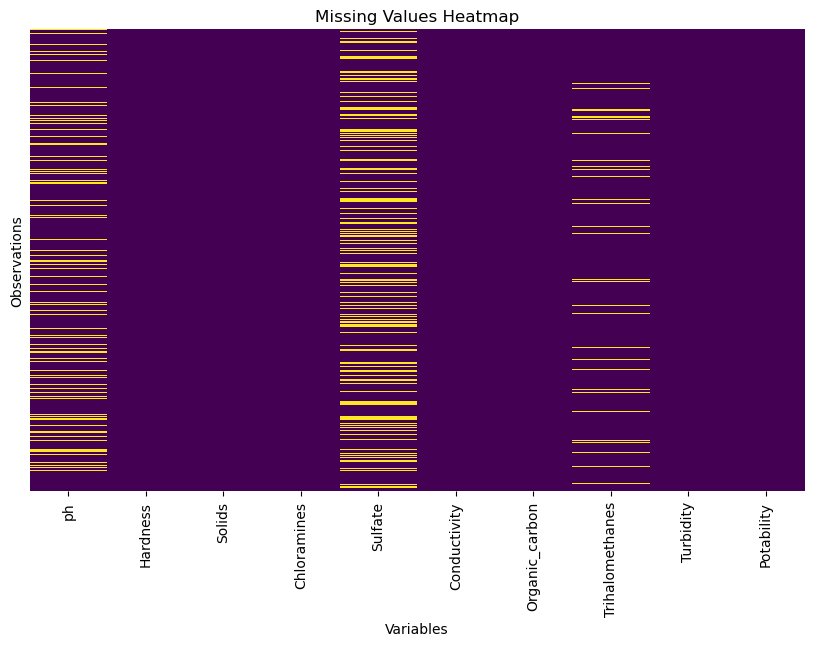

In [24]:
# Show Missing Data Distribution Visualisation 

# Set figure size
plt.figure(figsize=(10,6))

# Create heatmap to visualise missing values
sns.heatmap(water.isnull(), cbar=False, cmap='viridis', yticklabels=False)

# Add title to the plot
plt.title('Missing Values Heatmap')
plt.xlabel('Variables')
plt.ylabel('Observations')

# Display the plot
plt.show()

The Missing Data Visualisation confirms the patterns observed in both the column-based and row-based analyses. Missing values are primarily concentrated in **Sulfate, pH, and Trihalomethanes**, while the remaining variables are complete.<br>
From a row perspective, missing values are distributed across many observations, with **most rows containing zero or one missing value**. There is no evidence of rows with a high concentration of missing values.<br>
Additionally, the absence of clear **clusters (groups of observations with many missing values)** indicates that missing data does not follow a structured pattern, but instead occurs randomly across the dataset.<br>
This visual evidence further supports the use of **imputation techniques** rather than removing rows or columns.

#### 6.1.5 Missing Data Correlation

Missing Data Correlation examines the relationship between missing values across variables to determine whether missingness occurs simultaneously.<br>
Unlike the standard **Correlation Analysis of Numerical Values**, this approach focuses patterns of data absence rather than actual values.<br> 

- A value **close to 1** indicates that **missing values in two variables tend to ocurr in the same observations**
- A value **close to 0** indicates that **missing values occur independently** between variables

Understanding these relationships is important for selecting appropriate data handling strategies, particularly when deciding whether variables can be imputed separately or require more advanced techniques.

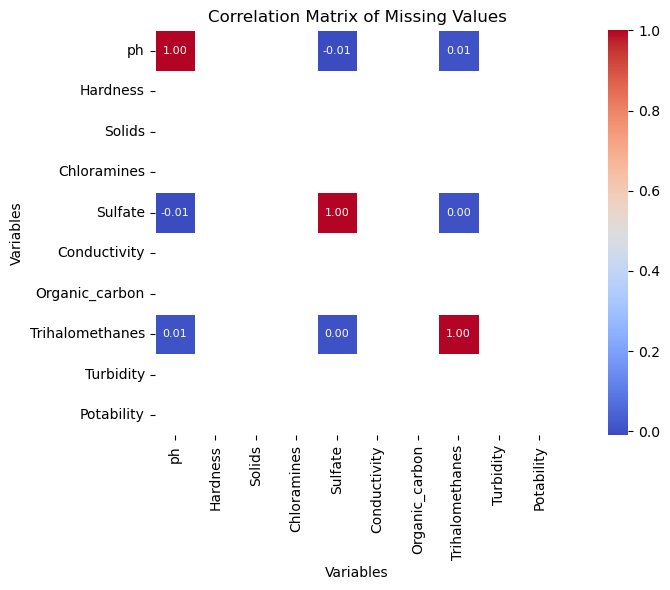

In [25]:
# Create missing values correlation matrix
missing_corr = water.isnull().corr()

# Set figure size
plt.figure(figsize=(10,6))

# Plot heatmap
sns.heatmap(missing_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, cbar=True, square=True, annot_kws={'size':8})

# Add titles and labels
plt.title("Correlation Matrix of Missing Values", fontsize=12)
plt.xlabel('Variables')
plt.ylabel('Variables')

# Improve layouts
plt.tight_layout()

#Show plot
plt.show()

The **Correlation Matrix of Missing Values** shows that the **relationships** between missing values across variables are **very weak**, with coefficients close to zero. This indicates that missingness does not occur simultaneously across variables and that there is no systematic pattern of missing data shared between them.<br>
In practical terms, this means that when a value is missing in one variable, it does not imply that values are also missing in other variables. Therefore, missing values can be treated independently for each feature.<br>
As a result, simple imputation techniques such as **mean or median** imputation are appropriate, as there is no need to apply more complex multivariate imputation methods.

### 6.2 Duplicate Data Analysis

Duplicate records are analysed to identify any repeated observations in the dataset.<br> 
Duplicate data can negatively affect the reliability of statistical analysis and machine learning models, as it may introduce bias or over-representation of certain patterns.

In [26]:
# Calculate total number of duplicated rows
duplicate_count = water.duplicated().sum()

# Display result
print(" Total number of duplicated rows in dthe dataset:", duplicate_count)

 Total number of duplicated rows in dthe dataset: 0


A total of **0 duplicated rows** were detected in the dataset. This confirms that there are no repeated observations and no risk of data redundancy.<br>
As a result, no duplicate removal is required, and the dataset is considered clean with respect to duplicated records.

## 7. Data Preprocessing

Data Preprocessing transforms the original dataset into a suitable format for machine learning. Based on the issues identified during the previous stages, this process enhances data consistency and prepares the dataset for subsequent model development.

In this study, the Data Preprocessing stage consists of three main steps:
<br>- **Data Cleaning**, to handle missing values and improve dataset consistency.
<br>- **Data Validation After Cleaning**, to verify that data distributions remain stable after preprocessing.
<br>- **Feature Engineering**, to prepare the dataset for machine learning modelling through scaling, transformation, multicollinearity and feature relevance prior to modelling.

Overall, this stage ensures that the dataset is **clean, consistent and properly prepared** for subsequent modelling, reducing potential bias and ensuring reliable machine learning model performance.

### 7.1 Data Cleaning

Data Cleaning is a fundamental step within **Data Preprocessing**, focused on correcting data quality issues identified during the previous analysis stage. This includes handling missing values and ensuring that the dataset is complete and consistent for subsequent modelling.<br>
Based on the **Data Quality Assessment**, the primary issue identified in this dataset is the presence of missing values, while no duplicate records are found. Therefore, the cleaning process focuses on addressing missing data appropriately.

#### 7.1.1 Missing Value Handling

Missing values are adressed using an imputation strategy informed by the **Data Quality Assessment**.<br>
**Row removal is not considered appropriate**, as missing are distributed across the dataset rather than concentrated in specific observations. Removing rows would significantly reduce the dataset size without substantial benefit.<br>
Similarly, **column removal is not justified**, since the proportion of missing values remains below commonly accepted thresholds (typically 40–50%). Additionally, the affected variables (pH, Sulfate and Trihalomethanes) are important water quality indicators and should be retained.<br>
Based on the **Distribution Analysis**, most variables are approximately symmetric, with the presence of some outliers. Since mean imputation is sensitive to extreme values, **median imputation was selected** as a more robust approach.<br>
Therefore, missing values in pH, Sulfate and Trihalomethanes were imputed using the median of each variable.

#### 7.1.2 Median Imputation

Median imputation is applied to the dataset by replacing missing values with the **median** of each corresponding variable. This approach ensures that missing values are handled in a consistent and robust manner.

In [27]:
# Create a copy of the original dataset
water_imputation = water.copy()

# Loop through each column
for col in water_imputation.columns:
    # Check if the column has missing values
    if water_imputation[col].isnull().sum() > 0:
        #Replace missing values with the median of the column
        water_imputation[col] = water_imputation[col].fillna(water_imputation[col].median())

#### 7.1.3 Post-Imputation Verification

After applying median imputation, the dataset is evaluated to verify whether missing have been successfully handled.<br>
This step ensures that the imputation process has been correctly implemented across all variables and that no incomplete data remains before proceeding to further analysis.

In [28]:
# Show the number of missing values in each column after imputation
water_imputation.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

The results indicate that all missing values have been successfully replaced across the dataset. This confirms that the imputation process has been correctly applied and that the dataset no longer contains incomplete observations.

#### 7.1.4 Final Dataset Overview

The final dataset is reviewed to confirm its structure and ensure that the data is ready for subsequent preprocessing and modelling steps.

In [29]:
# Display the first rows of the cleaned dataset
water_imputation.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [30]:
# Display dataset dimensions after cleaning
water_imputation.shape

(3276, 10)

The dataset preview shows that all variables contain valid numerical values and are consistently formatted.<br> 
Additionally, the dataset dimensions remain unchanged after cleaning, indicating that no observations were removed and only missing values were handled through imputation. The dataset is now complete and properly structured for further analysis.

### 7.2 Data Validation After Cleaning

After completing the **Data Cleaning** process, it is essential to validate that the transformations applied have not introduced unintended distortions in the dataset.<br>
This stage focuses on verifying that the statistical properties, distributions and relationships between variables and the target remain consistent after handling missing values.<br>
To achieve this, the distribution of the variables are re-examined and compared with their original patterns observed during the **EDA** stage. Tis includes analysing **Histograms** to assess distribution shape and **Boxplots** to evaluate the presence of extreme values.<br>
Additionally, the relationship between features and the target variable is reassessed to ensure that class separation patterns remain stable after data cleaning.<br>
This validation step ensures that the dataset remains **reliable, consistent and suitable** for subsequent **Feature Engineering** and model development stages.

#### 7.2.1 Bivariate Distribution Analysis (After Cleaning) 

The distribution of variables in relation to the target variable (Potability) was previously analysed during the **EDA** stage.<br> 
Following the **Data Cleaning** process, the analysis is revisited to assess whether the imputation of missing values has altered the underlying distributions or relationships between variables and the target.<br>
This step ensures that the dataset remains consistent and that no significant distortions have been introduced during preprocessing.

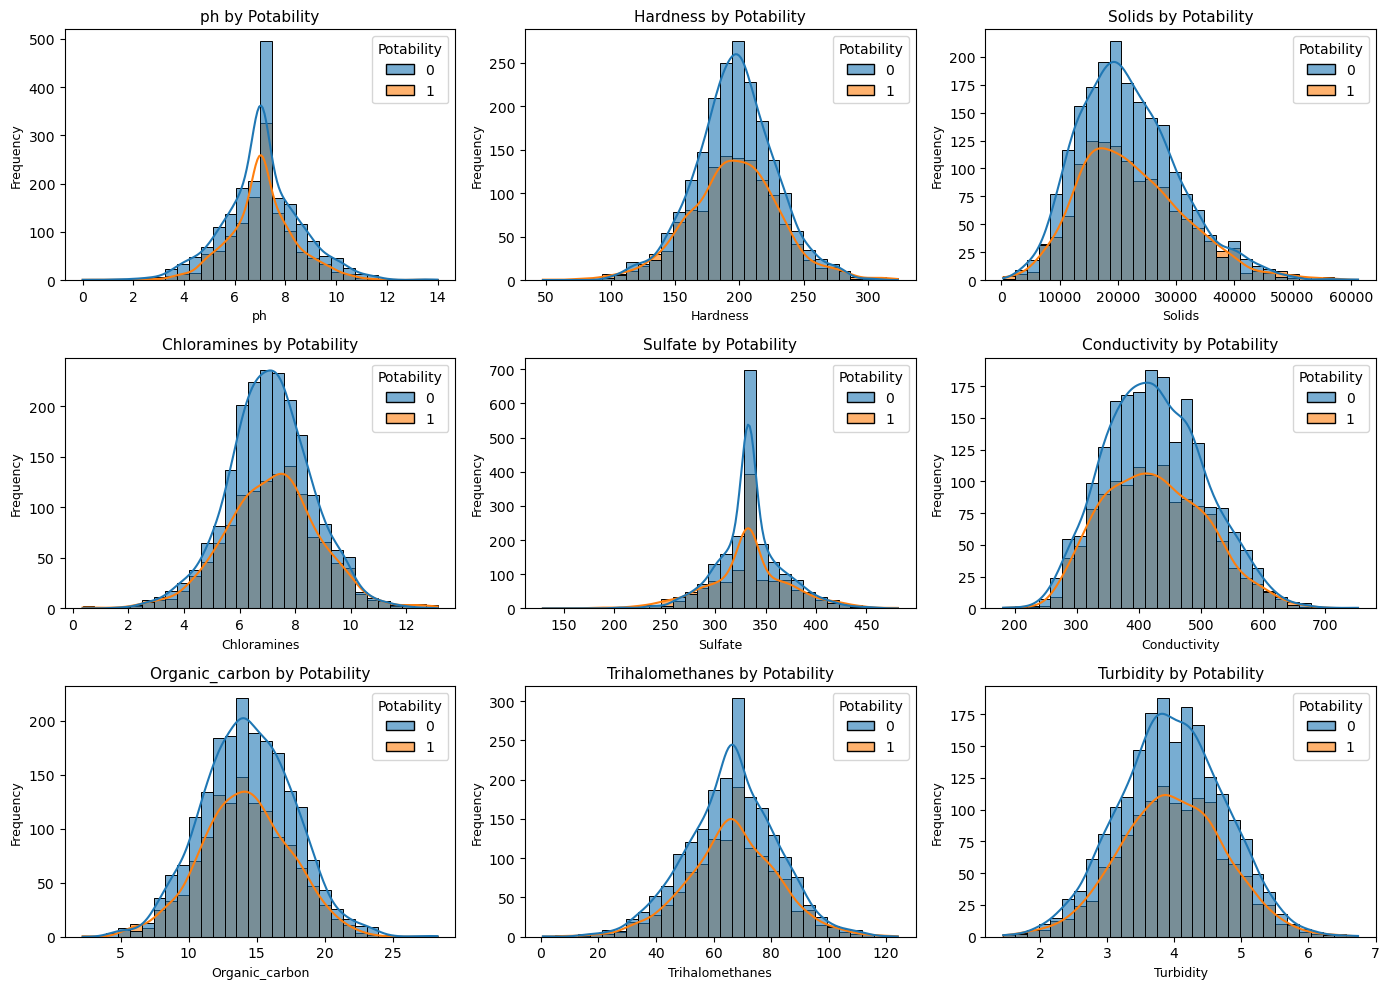

In [31]:
# Analyse feature distributions by target variable (Potability)

# Create figure and define layout
plt.figure(figsize=(14,10))

# Plot histograms for each feature grouped by Potability
for i, column in enumerate(features.columns, 1):
    plt.subplot(3, 3, i)    
    sns.histplot(data=water_imputation, x=column, hue='Potability', kde=True, bins=30, alpha=0.6 )    
    
    # Configure plot titles and axis labels
    plt.title(f'{column} by Potability', fontsize=11)
    plt.xlabel(column, fontsize=9)
    plt.ylabel('Frequency', fontsize=9)

# Adjust layout and display plots
plt.tight_layout()
plt.show()

After the imputation process, slight changes in the distribution are observed only in variables that originally contained missing values, namely pH, Sulfate and Trihalomethanes.<br>
These variables **exhibit noticeable peaks around specific values**, which are not present in the original distributions. This effect is a direct consequence of median imputation, where missing values are replaced by a single constant value (**the median**), leading to an artificial concentration of observations at that point.<br>
Despite this localized distortion, the overall shape of the distributions remains largely consistent with the original data. Therefore, the imputation process does not significantly alter the general structure of the dataset.<br>
This trade-off is acceptable because, although median imputation introduces a concentration of values at a single point, it provides robustness against outliers and preserves the overall structure of the data.

#### 7.2.2 Feature vs. Target Analysis (Boxplots)

To further explore the relationship between individual features and the target variable, boxplots are used to compare the distribution of each variable across the **two classes: non-potable water (0) and potable water (1)**.<br>
This analysis represents a **Bivariate Boxplot Analysis**, where each feature is examined in relation to the target variable (Potability). The goal is to assess whether a variable shows different distributions between the two classes.<br> 
A feature is considered to have discriminative power when the boxplots for each class show clear separation, particularly in their median values and interquartile ranges. In contrast, when there is significant overlap between the boxplots, the variable does not effectively distinguish between potable and non-potable water.<br>
Therefore, this analysis indicates which variables may contribute more effectively to classification and which ones provide limited information when considered individually.

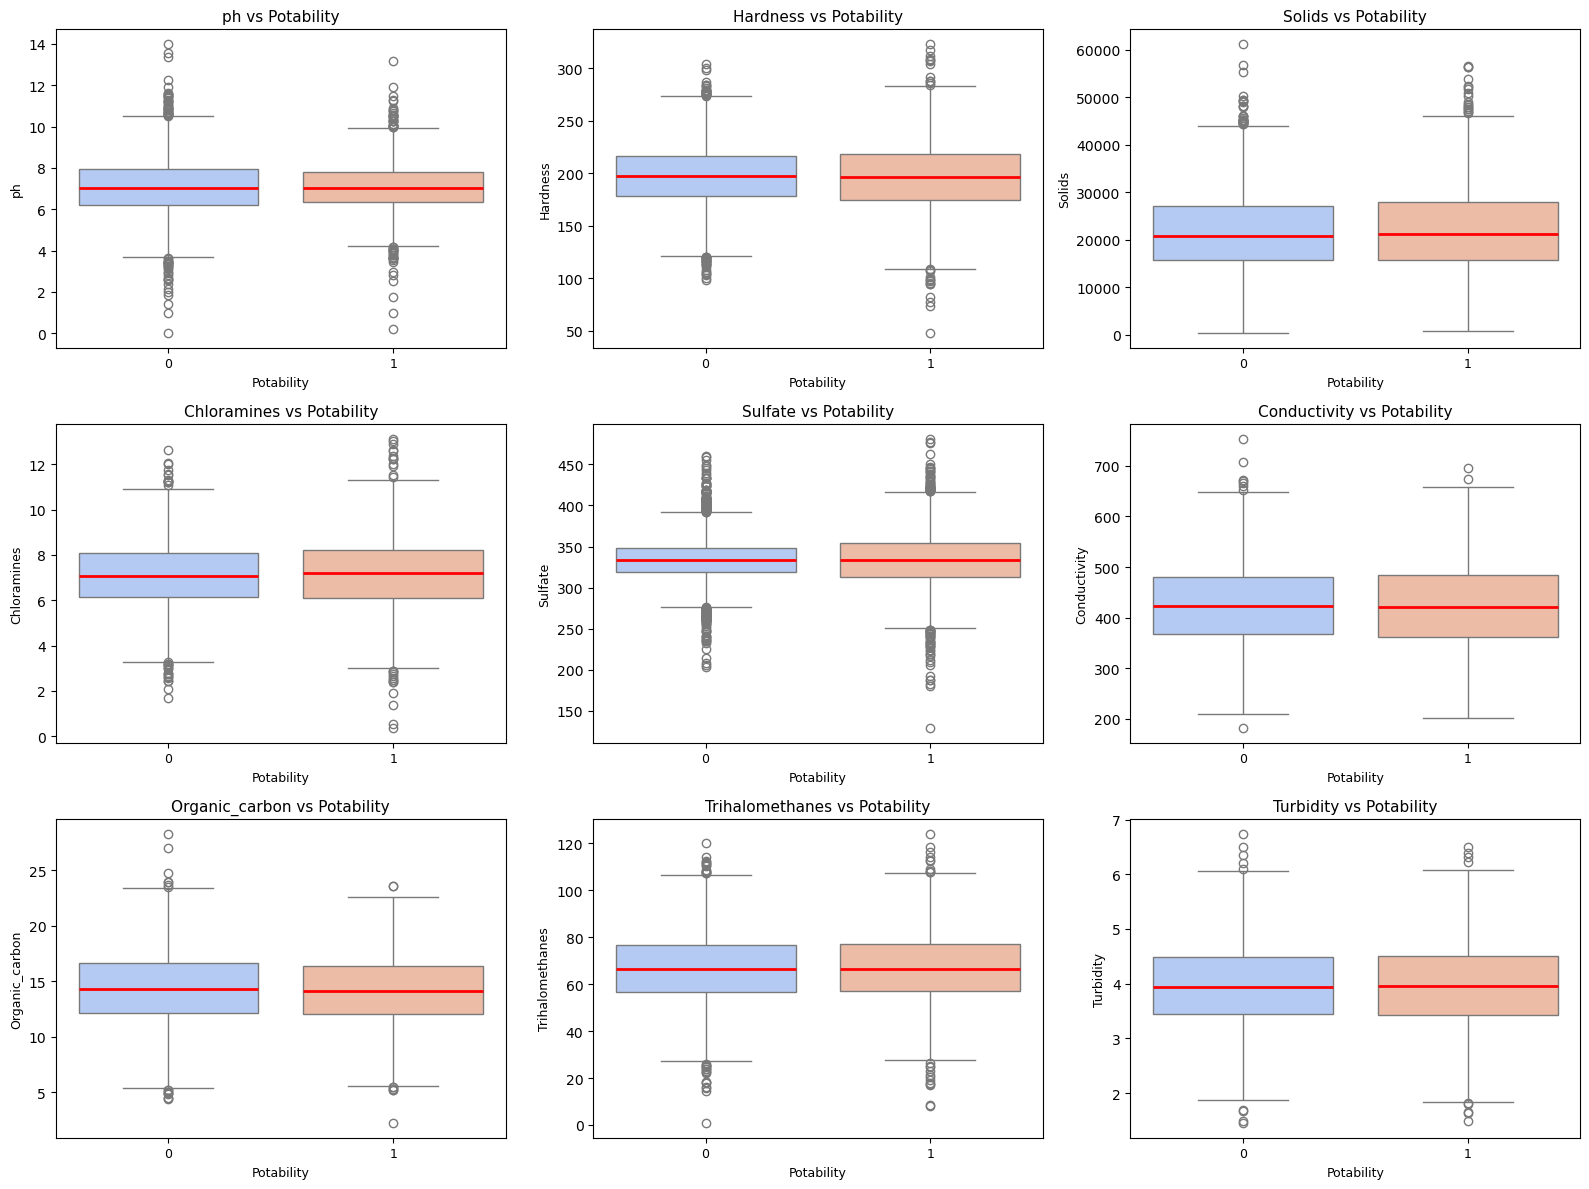

In [32]:
# Create figure and define layout
plt.figure(figsize=(16,12))

# Loop through each feature to generate boxplots against the target variable
for i, col in enumerate(features.columns, 1):
    # Define subplot position   
    plt.subplot(3, 3, i)
    # Create boxplot comparing feature distribution by Potability    
    sns.boxplot(x='Potability', y=col, data=water_imputation, hue='Potability', palette='coolwarm', dodge=False, legend=False, 
                medianprops=dict(color='red', linewidth=2))
    # Set plot title and labels    
    plt.title(f'{col} vs Potability', fontsize=11)
    plt.xlabel('Potability', fontsize=9)
    plt.ylabel(col, fontsize=9)
    plt.xticks(fontsize=9)
    
# Adjust layout for better spacing
plt.tight_layout()
# Display plots
plt.show()

The boxplot analysis shows a **strong overlap** between potable and non-potable water samples across most variables. This strong overlap means that the **median values** (central line in the box) and the **interquartile ranges** (the box itself, representing the middle 50% of the data) are very similar between both classes.<br>
In practical terms, this indicates that the same feature values can appear in both potable and non-potable water. For example, a given pH value may correspond to either classes, making it difficult to distinguish between them.<br>
If the boxplots were more separated (with different medians and less overlap), the feature would have better classification power. However, due to the overlap, individual variables are **not clearly distinguishable** between classes.<br>
Overall, water potability cannot be explained by a single variable and is instead influenced by the combined effect of multiple features.

### 7.3 Feature Engineering

Feature Engineering is a key step within **Data Preprocessing** that focuses on preparing and transforming variables to improve model performance while ensuring compatibility with machine learning algorithms.

This process includes techniques such as:
<br>- **Feature Scaling**, to standardize numerical ranges.
<br>- **Feature Transformation**, to address skewness and distribution issues.
<br>- **Categorical Encoding**, to convert non-numerical variables into numerical format.
<br>- **Multicollinearity Assessment**, to identify redundacy among features.
<br>- **Feature Selection Decision**, to decide which variables to retain or remove for model training.

In this dataset, all variables represent **physically meaningful environmental parameters**, which are directly related to water quality assessment.

Based on the results obtained during the **EDA**:
<br>- The dataset does not exhibit strong linear relationships between variables
<br>- Correlation values are generally weak, indicating low redundancy among features
<br>- No clear patterns or interactions justify the creation of additional derived variables

In scenarios where strong relationships or interactions exist, new features can be created (e.g., ratios between variables, interaction terms or domain-based combinations) to better capture underlying patterns.<br>
However, in this case, such transformations are not justified. Therefore, **no new features are created**, and the original variables are retained.<br>

####  7.3.1 Feature Scaling Assessment

This step is applied to standardize the range of numerical variables, ensuring that all features contribute equally to machine learning models.<br>
The analysis of feature ranges shows that variables such as Solids exhibit significantly larger numerical magnitudes compared to other variables. For example, Solids ranges from approximately 320 to over 61,000, while variables such as pH and **Turbidity operate within much smaller ranges.<br>
These differences reflect natural measurement units; however, they can negatively affect the performance of certain machine learning algorithms.<br>
Models such as **Logistic Regression, K-Nearest Neighbors and Support Vector Machines are sensitive to feature scale**, as they rely on distance calculations or gradient optimisation. In contrast, tree-based models such as **Random Forest and Gradient Boosting are not affected by scaling**.<br>
Common scaling techniques include **Standardization (StandardScaler)** and **Normalization (MinMaxScaler)**.<br>
Feature Scaling is applied to all numerical variables to ensure consistency across the dataset.
The scaling process is performed after splitting the dataset into training and testing sets. The scaler is fitted on the training data and then applied to both training and test sets to prevent data leakage.<br>
Therefore, **Feature Scaling is applied** only to scale-sensitive models to ensure compatibility across all evaluated models. The specific scaling method is implemented during the **Data Preparation for Modelling** stage.

#### 7.3.2 Feature Transformation

This step refers to techniques used to modify the distribution (shape) of numerical variables, typically to reduce skewness and improve statistical properties.<br>
Common transformation techniques include **Logarithmic**, **Square Root** and **Box-Cox** transformations.<br>
In general, variables with **skewness values greater than 1 or lower than -1** are considered highly skewed and **may require transformation**.<br>
Based on the **Skewness Analysis** conducted during the **EDA** phase, most variables in the dataset exhibit approximately symmetric distributions, with skewness values close to zero.<br>
Although some variables, such as Solids, show moderate positive skewness, the magnitude is not sufficiently high to justify transformation.<br>
Therefore, **Feature Transformation is not applied** in this study, as the dataset does not exhibit strong asymmetry that would significantly impact model performance.

#### 7.3.3 Categorical Encoding

This process involves **converting categorical variables into numerical representations** so that they can be used in machine learning algorithms.<br>
Common encoding techniques include **One-Hot**, **Label** and **Ordinal** encoding methods, depending on the nature of the categorical data.<br>
Encoding is an essential **Data Preprocessing** step when working with datasets that contain non-numerical variables, as most machine learning models require numerical input.<br>
In this case, **Categorical Encoding is not applied**, as all variables in the dataset are already numerical and represent continuous physicochemical measurements.Therefore, no transformation of categorical data is required.

#### 7.3.4 Multicollinearity Assessment

While **Correlation Analysis** evaluates pairwise relationships between variables, it may not fully capture more complex dependencies involving multiple variables simultaneously.<br>
Therefore, **Multicollinearity** is further assessed using the **Variance Inflation Factor (VIF)**.<br>
Multicollinearity refers to a situation in which a variable can be partially explained by a combination of other variables in the dataset, indicating the presence of overlapping or redundant information among features.<br>
The **VIF** measures how strongly a feature is linearly associated with all other independent variables combined. Higher VIF values indicate greater redundancy and stronger multicollinearity among variables.<br>
Additionally, dimensionality reduction techniques such as **Principal Component Analysis (PCA)** are commonly considered when datasets exhibit excessive multicollinearity or a large number of highly correlated variables. PCA transforms the original variables into a smaller set of uncorrelated components while preserving most of the dataset variance.<br>
However, in this study, **PCA is not applied**. Although several variables exhibit high VIF values, preserving the interpretability and physical meaning of the original environmental parameters is considered more important for water quality assessment.

In [33]:
# Independent variables
X = water_imputation.drop(columns=['Potability'])
# Dependent variable
y = water_imputation['Potability']

# Create DataFrame to store VIF results
vif_data = pd.DataFrame()
vif_data["Parameter"] = X.columns

# Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# Display VIF results
vif_data.style.hide(axis="index").format({"VIF": "{:.3f}"})

Parameter,VIF
ph,22.809
Hardness,30.836
Solids,6.970
Chloramines,19.586
Sulfate,56.176
Conductivity,25.979
Organic_carbon,18.695
Trihalomethanes,17.372
Turbidity,24.129


The interpretation of VIF values can be summarised as follows:

| VIF value | Interpretation |
|------------------------|----------------|
| ≈ 1 | No multicollinearity |
| 1 - 5 | Low to moderate multicollinearity |
| 5 - 10 | Moderate to high multicollinearity |
| > 10 | High multicollinearity (potential concern) |

The **VIF results** indicate that several variables exhibit relatively **high multicollinearity**, with VIF values greater than 10.<br>
This suggests that some features share overlapping information and may be partially explained by combinations of other variables. Only the variable **Solids** presents a comparatively **lower VIF** value (approximately 7), indicating moderate multicollinearity relative to the remaining features.<br>
Overall, the dataset exhibits a **notable degree of multicollinearity** which is expected in environmental datasets where physicochemical parameters are naturally interconnected through shared environmental processes.

#### 7.3.5 Feature Selection Decision

Despite the presence of relatively high multicollinearity indicated by the **VIF** analysis, **no features are removed** from the dataset.<br>
This behavior is common in environmental datasets, where physicochemical parameters are naturally interrelated and influenced by shared underlying processes. Therefore, a certain degree of multicollinearity is expected and does not necessarily indicate poor data quality.<br>
Removing variables solely based on **VIF** values could result in the loss of environmentally relevant information, particularly in datasets where multiple variables jointly describe complex water quality conditions.<br>
Furthermore, several machine learning models selected for this study, including **Random Forest (RF)** and **Gradient Boosting (GB)**, are relatively robust to multicollinearity due to their non-linear learning structure and ability to capture feature interactions.<br>
In contrast, models such as **Logistic Regression (LR)** and **K-Nearest Neighbors (KNN)** may be more sensitive to feature relationships and variable scaling. **Support Vector Machine (SVM)** can also be influenced by feature scaling and data struture, although they are generally less affected by multicollinearity than purely linear models.<br>
However, the primary objective of this study focuses on predictive performance and environmental interpretation rather than strict coefficient interpretability.<br>
Therefore, all original variables are retained for subsequent **Data Preparation for Modelling**.

## 8. Dataset Preparation For Modelling

Dataset Preparation for Modelling prepares the dataset for machine learning training and evaluation by organising the data into a suitable format before model development.<br>

In this study, the Dataset Preparation for Modelling consists of the following key steps:
<br>- **Features and Target Definition**, to separate predictor variables from the target variable used for classification.
<br>- **Train-Test Split**, to divide the dataset into training and testing subsets while preserving class distribution.
<br>- **Feature Scaling Application**, to standardize numerical feature ranges for scale-sensitive machine learning algorithms.
<br>- **Class Imbalance Assessment**, to evaluate the distribution of potable and non-potable water samples to modelling.

Overall, this stage ensures that the dataset is **properly structured** and ready for machine learning modelling.

### 8.1 Features and Target Definition

In supervised machine learning, the dataset is divided into **independent variables (features)** and the **dependent variable (target)**. The target variable represents the outcome to be predicted, while the features contain the input information used by the models.

In this study, the **variable Potability** is defined as the target variable, where:
<br>- **1** = Potable water
<br>- **0** = Non-potable water<br>

All remaining physicochemical parameters are used as **predictor variables (features)**.

In [34]:
# Define independent variables or features (X) 
X = water_imputation.drop(columns="Potability")

# Define dependent variable or target (y)
y = water_imputation["Potability"]

# Verify shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3276, 9)
y shape: (3276,)


The dataset is now separated into features (X) and the target variable (y). preparing it for the **Train-Test Split** stage and subsequent machine leaning modelling.

### 8.2 Class Imbalance Assessment

Class distribution analysis is performed to evaluate whether the target variable **exhibits imbalance between potable and non-potable** water classes.<br>
The distribution of the target classes is examined using both numerical summaries and graphical visualization. Understanding class proportions is important because highly imbalanced datasets may bias machine learning models toward the majority class.

In [35]:
# Create class distribution summary
class_summary = pd.DataFrame({'Count': y.value_counts(), 'Percentage (%)': y.value_counts(normalize=True)*100})

# Reorder rows manually
class_summary = class_summary.reindex([1, 0])

# Rename index labels
class_summary.index = ['Potable (1)', 'Non-potable (0)']

# Format percentages
class_summary['Percentage (%)'] = class_summary['Percentage (%)'].round(2)

# Display table
class_summary

,Count,Percentage (%)
Potable (1),1278,39.01
Non-potable (0),1998,60.99


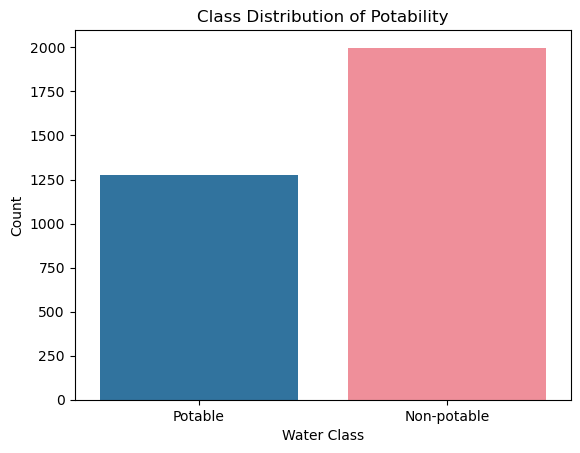

In [36]:
# Create count plot
sns.countplot(x=y.map({1: 'Potable', 0: 'Non-potable'}), order=['Potable', 'Non-potable'], palette=['#1f77b0', '#ff7f8e'])

# Set title
plt.title("Class Distribution of Potability")

# Set axis labels
plt.xlabel("Water Class")
plt.ylabel("Count")

# Show plot
plt.show()

Class imbalance severity can be interpreted as follows:

| Imbalance | Interpretation |
|------------------------|----------------|
| 50/50 | Perfect balance |
| 60/40 | Slight imbalance |
| 70/30 | Moderate imbalance |
| 80/20 | Severe imbalance |

The class distribution analysis shows that approximately **61%** of the samples correspond to **non-potable water**, while **39%** correspond to **potable water**.<br>
Based on the observed proportions, the dataset **exhibits a slight class imbalance**. However, the imbalance is not sufficiently severe to require corrective techniques such as resampling.<br>
In machine learning, **resampling techniques** are commonly applied when datasets exhibit moderate or severe class imbalance. These methods aim to improve class representation and reduce prediction bias toward the majority class.<br>

Common resampling approaches include:
<br>- **SMOTE (Synthetic Minority Oversampling Technique)**: generates synthetic samples for the minority class.
<br>- **Random Oversampling**: duplicates minority class observations.
<br>- **Random Undersampling**: reduces observations from the majority class.
<br>- **Class Weighting**: increases the penalty for misclassifying minority class samples during model training.

Since the observed imbalance in this dataset is relatively slight, **no resampling techniques are applied** at this stage.

### 8.3 Train-Test Split

To evaluate model performance objectively, the dataset is divided into **80% training** and **20% testing** subsets. The training set is used to train the machine learning models, while the testing set is reserved for evaluating model generalisation on unseen data.<br>
To further verify the consistency of the stratified split, the number of potable and non-potable samples within the training and testing datasets is also examined. 

In [37]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create class distribution summary
split_summary = pd.DataFrame({ 'Training Set': y_train.value_counts(normalize=True), 'Testing Set': y_test.value_counts(normalize=True)})

# Reorder rows manually
split_summary = split_summary.reindex([1, 0])

# Rename index labels
split_summary.index = ['Potable (1)', 'Non-potable (0)']

# Display table
split_summary.style.format({"Training Set": "{:.3f}", "Testing Set": "{:.3f}"})

,Training Set,Testing Set
Potable (1),0.390,0.390
Non-potable (0),0.610,0.610


The dataset was successfully divided into **80% training** data and **20% testing** data while **preserving the original class distribution of the target** variable. This ensures consistent representation of potable and non-potable water samples across both datasets.<br>
**Stratified splitting was applied using stratify=y** to mantain consistent porportions of potable and non-potable water samples across both datasets.

In [38]:
# Create class distribution summary for training and testing sets
train_test_distribution = pd.DataFrame({'Training Set': y_train.value_counts(), 'Testing Set': y_test.value_counts()})

# Reorder rows manually
train_test_distribution = train_test_distribution.reindex([1, 0])

# Rename index labels
train_test_distribution.index = ['Potable (1)', 'Non-potable (0)']

# Display class distribution table
train_test_distribution

,Training Set,Testing Set
Potable (1),1022,256
Non-potable (0),1598,400


The table above shows the numerical distribution of potable and non-potable water samples within the training and testing datasets. The proportions remain approximately consistent across both subsets due to the application of **stratified sampling** during the train-test split process.

### 8.4 Feature Scaling Application 

Feature Scaling is applied after the **Train-Test Split** using **StandardScaler**.<br>
The scaler is fitted exclusively on the training data and then applied to both the training and testing sets using the same scaling parameters. This approach prevents data leakage and ensures consistency between datasets.<br>
Scaling is particularly important for scale-sensitive algorithms such as **Logistic Regression (LR), K-Nearest Neighbors (KNN) and Support Vector Machine (SVM)**.

In [39]:
# Create scaler object
scaler = StandardScaler()

# Fit scaler only on training data and transform trainig set
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaling transformation to testing set
X_test_scaled = scaler.transform(X_test)

The scaling process was successfully completed, producing standardized training and testing datasets for subsequent machine learning modelling.<br>
The transformed datasets are now suitable for scale-sensitive algorithms, while maintaining methodological consistency and preventing information leakage between subsets.

## 9. Model Selection and Training

Model Selection and Training is a fundamental stage in the machine learning workflow, focused on selecting, training and performing the initial evaluation of machine learning models for water potability classification.

In this study, the Model Selection and Training consists of the following key stages:
<br>- **Model Selection Rationale**, to justify the selection of different machine learning algorithms suitable for binary classification problems.
<br>- **Logistic Regression (LR)**, to establish a baseline linear classification model for water potability prediction.
<br>- **K-Nearest Neighbors (KNN)**, to evaluate distance-based classification performance using neighboring observations.
<br>- **Support Vector Machine (SVM)**, to analyze classification performance using margin-based separation techniques.
<br>- **Gradient Boosting (GB)**, to assess boosting-based ensemble learning for improved predictive performance.
<br>- **Random Forest (RF)**, to evaluate ensemble learning performance through multiple decision trees.
<br>- **Initial Model Comparison**, to compare model performance using Accuracy, Classification Reports and Confusion Matrices.

Overall, this stage provides the **initial predictive evaluation of the selected machine learning models** and establishes the baseline for the advanced validation techniques presented in the following chapter.

### 9.1 Model Selection Rationale

The selection of machine learning models in this study aims to compare different classification approaches for water potability prediction using models with varying learning strategies and complexity levels.

Five classification models are evaluated in this study:
<br> - **Logistic Regression (LR)**, representing a linear baseline classification model,
<br> - **K-Nearest Neighbors (KNN)**, representing a distance-based classification model,
<br> - **Support Vector Machine (SVM)**, representing a margin-based classication model,
<br> - **Gradient Boosting (GB)**, representing a sequential tree-based ensemble classification model.
<br> - **Random Forest (RF)**, representing a tree-based ensemble classification model,

Environmental datasets often exhibit non-linear relationships, multicollinearity, variable interactions and heterogeneous data distributions. Therefore, ensemble and non-linear models such as **RF, GB and SVM are expected to better capture complex patterns** within the dataset.<br>
However, simpler models such as **LR and KNN are also included to provide baseline references** and allow performance comparison between linear, distance-based and ensemble learning approaches.<br>
Additionally, previous exploratory analysis identified moderate skewness, multicollinearity and variable scale differences among features. As a result, feature scaling is applied for scale-sensitive models such as LR, KNN and SVM, while tree-based models are trained using the original feature scales.

### 9.2 Hyperparameter Initialisation

Before training the machine learning models, an initial **set of hyperparameters** is defined for each algorithm. Hyperparameters are configuration settings specified before the training process that control how a learning algorithm is built. Unlike model parameters, which are learned automatically during training, hyperparameters are selected by the user and can significantly influence predictive performance and model generalisation.<br>
Each model is initialised using a single baseline configuration of hyperparameters to ensure a consistent and fair comparison during the initial evaluation. Examples of the hyperparameters considered include: **C, solver, max_iter, random_state, n_neighbors, weights, metric, p, gamma, kernel, probability, n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features and learning_rate**.<br>
These initial configuration establish the baseline performance of each model. After the initial model evaluation, the best-performing candidate models are subsequently selected for **Hyperparameter Tuning**, where wider ranges of hyperparameter values are systematically explored to further improve predictive performance and model generalisation. This optimisation process is presented in the **Model Optimisation** section.

### 9.3 Logistic Regression (LR)

Logistic Regression (LR) is a supervised linear classification algorithm commonly used as a baseline model due to its simplicity, interpretability and computational efficiency.<br>
LR generally performs better when predictor variable are properly scaled and when relationships within the dataset are relatively simple. Since **LR is sensitive to feature magnitude differences**, standardized features are used during model training.<br>
In this study, LR is included as a baseline reference model to compare its performance with more advanced machine learning approaches.

In [40]:
# Initialise LR model
lr_model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)

# Train model
lr_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_lr = lr_model.predict(X_test_scaled)

LR is implemented as a linear classification model that estimates the relationship between water quality features and potability outcomes. Its simplicity and interpretability make it useful as a baseline reference for comparison with more complex machine learning models.

### 9.4 K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised distance-based classification algorithm that classifies observations based on similarities between neighboring samples in feature space.<br>
**KNN performs better when features are properly scaled**, since distance calculations are sensitive to variable magnitude differences. Therefore, standardized features are used during model training.<br>
In this study, KNN is included to evaluate the ability of distance-based learning to capture local similarities and patterns within the water quality dataset.

In [41]:
# Initialise KNN model
knn_model = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski', p=2)

# Train model
knn_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_knn = knn_model.predict(X_test_scaled)

KNN is implemented as a distance-based classification model that predicts class membership according to similarities between neighbouring observations in feature space. The model captures local patterns in the dataset by comparing observations with similar physicochemical characteristics.

### 9.5 Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised margin-based classification algorithm designed to separate classes by identifying an optimal boundary between categories.<br>
**SVM performs well in datasets with complex relationships** and is particularly useful when classes are not easily separated using simple linear methods. Since **SVM is sensitive to feature magnitude differences**, standardised features are used during model training.<br>
In this study, SVM is included to evaluate the ability of advanced classification boundaries to distinguish potable from non-potable water samples.

In [42]:
# Initialise SVM model
svm_model = SVC(C=1.0, gamma='scale', kernel='rbf', probability=True, random_state=42)   # Enable probability estimates for ROC-AUC (predict_proba())

# Train model
svm_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_svm = svm_model.predict(X_test_scaled)

SVM is implemented as a margin-based classification model that attempts to maximise class separation using an optimal decision boundary. This approach allows the model to handle complex relationships within the water quality dataset.

### 9.6 Gradient Boosting (GB)

Gradient Boosting (GB) is a supervised tree-based ensemble classification algorithm that builds decision trees sequentially to improve prediction performance.<br>
Unlike RF, where trees are created independently, **GB trains each new tree to correct errors made by previous trees**. This approach is effective for capturing complex and non-linear relationships within the dataset.<br>
**GB is not sensitive to feature magnitude differences**, since tree-based models do not rely on distance calculations or gradient-based feature scaling. Therefore, standardised features are not required during model training.<br>
In this study, GB is included to evaluate whether sequential ensemble learning can improve water potability classification performance.

In [43]:
# Initialise GB model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2, min_samples_leaf=1, random_state=42)

# Train model
gb_model.fit(X_train, y_train)

# Generate predictions
y_pred_gb = gb_model.predict(X_test)

GB is implemented as a sequential ensemble learning model in which each decision tree attempts to reduce the errors generated by previous trees. This iterative learning process allows the model to capture complex patterns and improve predictive performance in water quality classification tasks.

### 9.7 Random Forest (RF)

Random Forest (RF) is a supervised tree-based ensemble classification algorithm that combines multiple decision trees to improve classification performance and reduce overfitting.<br>
**RF performs well in datasets with complex and non-linear relationships**, as it can capture interactions between variables without requiring linear assumptions. Unlike distance-based and linear models, **RF is not sensitive to feature magnitude differences**, therefore feature scaling is not required during model training.<br>
In this study, RF is included to evaluate the ability of ensemble learning to improve the classification of potable and non-potable water samples through combined decision-tree predictions.

In [44]:
# Initialise RF model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Generate predictions
y_pred_rf = rf_model.predict(X_test)

RF is implemented as an ensemble learning model that combines multiple decision trees to improve classification stability and reduce overfitting. Its tree-based structure allows the model to capture complex variable interactions within the dataset.

### 9.8 Initial Model Comparison

After training the machine learning models, an initial performance evaluation is conducted to assess how accurately each model classifies potable and non-potable water samples.<br>
Several evaluation metrics are used, including **Accuracy, Classification Reports and Confusion Matrices**. These metrics help measure overall prediction performance, identify classification errors and compare the strengths and limitations of each model.<br>
These evaluation metrics are calculated **using a single decision threshold (typically 0.50)**, providing an initial assessment of model performance under one classification criterion.<br>
This initial comparison provides a general understanding of model behaviour before performing more advanced evaluation and optimisation procedures, such as **ROC Curve and AUC Analysis, Overfitting Assessment, Cross-Validation and Hyperparameter Tuning**.

#### 9.8.1 Accuracy

Accuracy is used as an initial evaluation metric to **measure the proportion of correctly classified observations within the test dataset**. In binary classification problems, where observations are classified into two categories **(1 = potable and 0 = non-potable)**, accuracy represents the ratio of correct predictions relative to the total number of observations.<br> 
Although accuracy provides a general overview of model performance, it may not fully reflect classification quality when class imbalance or critical prediction errors are present. Therefore, Accuracy should be interpreted together with **additional evaluation metrics** to obtain a more comprehensive assessment of model performance

In [45]:
# Store model accuracy scores
base_model_accuracy = {"Logistic Regression (LR)": accuracy_score(y_test, y_pred_lr), "K-Nearest Neighbors (KNN)": accuracy_score(y_test, y_pred_knn), 
                    "Support Vector Machine (SVM)": accuracy_score(y_test, y_pred_svm), "Gradient Boosting (GB)": accuracy_score(y_test, y_pred_gb), 
                    "Random Forest (RF)": accuracy_score(y_test, y_pred_rf)}

# Convert results to DataFrame and sort by accuracy
accuracy_base_table = pd.DataFrame(base_model_accuracy.items(), columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)

# Display sorted acuracy results
accuracy_base_table.style.hide(axis='index').format({'Accuracy': '{:.3f}'})

Model,Accuracy
Support Vector Machine (SVM),0.671
Random Forest (RF),0.659
Gradient Boosting (GB),0.652
K-Nearest Neighbors (KNN),0.614
Logistic Regression (LR),0.610


Accuracy performance can generally be interpreted as follows:

| Accuracy Range | Interpretation |
|----------------|----------------|
| 0.00 - 0.50    | Poor performance |
| 0.50 - 0.60    | Weak performance |
| 0.60 – 0.70    | Moderate performance |
| 0.70 – 0.80    | Good performance |
| 0.80 - 0.90    | Strong performance |
| 0.90 - 1.00    | Excellent performance |

In this study, SVM achieved the highest overall accuracy (67.07%), meaning that approximately 67 out of every 100 test observations were correctly classified.RF and GB followed closely, while KNN and LR demonstrated slightly lower predictive performance. Although SVM achieved the highest accuracy, all evaluated models fall within the **Moderate Performance** range, suggesting that further evaluation is required before selecting the most appropriate model for water potability prediction.<br>
However, the relatively small differences observed among the evaluated models suggest that accuracy alone is insufficient for selecting the most appropriate model. Since water potability prediction involves different types of classification errors with varying practical consequences, additional evaluation metrics such as **Precision, Recall, F1-Score and Confusion Matrices** are required to provide a more reliable assessment of model performance. These metrics are analysed in the following sections.

#### 9.8.2 Classification Reports  

Classification Reports are used to provide a more detailed evaluation of classification performance beyond overall **Accuracy**. In binary classification problems, these reports summarise key metrics such as **Precision, Recall and F1-score** for each class, together with **Support** values and aggregated measures including **Macro Average and Weighted Average**.

- **Precision** indicates how reliable the model is when predicting a specific class. It answers the question: “When the model predicts a class, how often is it correct?”.
- **Recall** indicates how effectively the model detects the actual samples of a class. It answers the question: “Out of all real samples belonging to a class, how many were correctly identified?”.
- **F1-score** provides a balanced measure between **Precision and Recall** and is especially useful when both detection capability and prediction reliability are important. It is calculated as:
F1-score = 2 × (Precision × Recall) / (Precision + Recall).
- **Support** represents the total number of actual observations belonging to each class within the **test dataset**.
- **Macro Average** computes the simple average of the evaluation metrics across all classes, treating each class equally.
- **Weighted Average** computes the average of the evaluation metrics weighted according to the number of samples in each class.

In water potability prediction, Classification Reports provide more meaningful insights than Accuracy alone, specially for evaluating the detection of **potable water samples (class 1)**

In [46]:
# Create separator line for better report visualization
separator = "\n" + "="*55 

# Display LR Classification Report
print(separator)
print("Logistic Regression (LR) Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

# Display KNN Classification Report
print(separator)
print("K-Nearest Neighbors (KNN) Classification Report:\n")
print(classification_report(y_test, y_pred_knn))

# Display SVM Classification Report
print(separator)
print("Support Vector Machine (SVM) Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

# Display GB Classification Report
print(separator)
print("Gradient Boosting (GB) Report:\n")
print(classification_report(y_test, y_pred_gb))

# Display RF Classification Report
print(separator)
print("Random Forst (RF) Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Display final separator
print(separator)


Logistic Regression (LR) Classification Report:

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656


K-Nearest Neighbors (KNN) Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.80      0.72       400
           1       0.51      0.32      0.39       256

    accuracy                           0.61       656
   macro avg       0.58      0.56      0.56       656
weighted avg       0.59      0.61      0.59       656


Support Vector Machine (SVM) Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.93      0.77       400
           1       0.70      0.27      0.39       256

    accuracy               

In [54]:
# Store model predictions
model1 = {"Logistic Regression (LR)": y_pred_lr, "K-Nearest Neighbors (KNN)": y_pred_knn, "Support Vector Machine (SVM)": y_pred_svm, 
         "Gradient Boosting (GB)": y_pred_gb, "Random Forest (RF)": y_pred_rf}

# Store Classification Report metrics for potable water (Class 1)
report_table = []

# Extract Preicsion, Recall and F1-score for potable water (Class 1)
for name, y_pred in model1.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    report_table.append({"Model": name, "Precision": report["1"]["precision"], "Recall": report["1"]["recall"], 
                         "F1-score": report["1"]["f1-score"]})

# Create comparison table
classification_base_table = pd.DataFrame(report_table)

# Sort by F1-score(highest to lowest)
classification_base_table = classification_base_table.sort_values(by="F1-score", ascending=False)

# Display the table
classification_base_table.style.hide(axis='index').format({'Precision': '{:.3f}', 'Recall': '{:.3f}', 'F1-score': '{:.3f}'})                                                    

Model,Precision,Recall,F1-score
Random Forest (RF),0.631,0.301,0.407
K-Nearest Neighbors (KNN),0.509,0.320,0.393
Support Vector Machine (SVM),0.704,0.270,0.390
Gradient Boosting (GB),0.643,0.246,0.356
Logistic Regression (LR),0.000,0.000,0.000


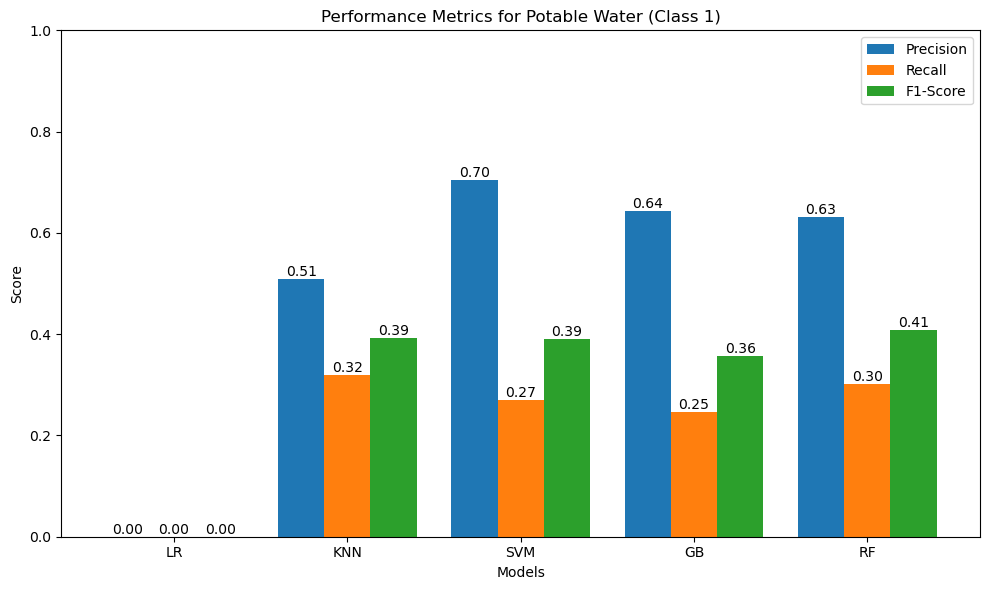

In [55]:
# Store model predictions
model2 = {"LR": y_pred_lr, "KNN": y_pred_knn, "SVM": y_pred_svm, "GB": y_pred_gb, "RF": y_pred_rf}

# Extract metrics for Potable Water (Class 1)
metrics = []
for model, y_pred in model2.items():
    report = classification_report(y_test, y_pred, output_dict=True)  
    metrics.append({"Model": model, "Precision": report["1"]["precision"], "Recall": report["1"]["recall"], "F1-Score": report["1"]["f1-score"]})

# Create comparison dataframe
df_metrics = pd.DataFrame(metrics).set_index("Model")

# Plot performance metrics
ax = df_metrics.plot(kind="bar", figsize=(10,6), width=0.8)
plt.title("Performance Metrics for Potable Water (Class 1)")
plt.ylabel("Score")
plt.xlabel("Models")
plt.ylim(0,1)

# Display model names horizontally
plt.xticks(rotation=0)

# Display values on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.tight_layout()
plt.show()

In this study, particular attention is given to the **potable water class (class 1)**, as misclassifying contaminated water as potable may represent a serious environmental and public health risk. Therefore, evaluation should not rely solely on Accuracy, but also consider **Precision, Recall, and F1-score for class 1**.<br>

- **LR model** fails to identify potable water samples, predicting all observations as non-potable. Consequently, **Precision, Recall and F1-score for class 1 are equal to zero**. Although the model achieves an accuracy of 61% due to correct classification of non-potable water, it is **unsuitable for practical potable water prediction**.<br>
- **KNN model** demonstrates moderate capability for detecting potable water samples and achieves **the highest Recall (32%)** among the evaluated models, indicating the greatest ability to identify actual potable water samples. However, its relatively low Precision (51%) and F1-score (39%) indicate that **many potable predictions remain unreliable** and a considerable number of potable samples are **still misclassified as non-potable**.<br>
- **SVM model** achieves **the highest Precision for potable water (70%)**, indicating that samples predicted as potable are more likely to be truly potable. However, its Recall remains low (27%), meaning that **many actual potable samples are not detected**. This suggests a conservative classification behaviour that prioritizes prediction reliability over potable water detection.<br>
- **GB model** showes behavior **similar to RF**, although with slightly lower Recall and F1-score for potable water samples.<br>
- **RF model** produces **the highest F1-score for potable water classification (41%)**, indicating the best overall balance between Precision and Recall among the evaluated models. Although its Recall remains moderate (30%), this model **provides the most balanced performance for potable water detection** while maintaining acceptable prediction reliability.<br>

Overall, the evaluated models exhibit different strengths: KNN shows the highest Recall, SVM provides the highest Precision and RF achieves the highest F1-score. Considering the environmental and public health implications of water potability prediction, **RF provides the most reliable overall classification performance among the evaluated models**.<br>
Nevertheless, none of the evaluated models achieve high Recall for potable water samples, indicating that a substantial proportion of actual potable observations remain undetected. This suggests that further model optimisation, class balancing techniques, hyperparameter tuning or threshold adjustment may be required to improve potable water detection performance.

#### 9.8.3 Confusion Matrices 

Confusion Matrices are used to provide a detailed visual representation of classification performance by comparing actual and predicted class labels. In binary classification problems, confusion matrices allow the identification of correctly and incorrectly classified observations for each class.

The confusion matrix is composed of four key components:
<br>- **True Positives (TP)**: potable water samples correctly classified as potable.
<br>- **True Negatives (TN)**: non-potable water samples correctly classified as non-potable.
<br>- **False Positives (FP)**: non-potable water samples incorrectly classified as potable (critical error).
<br>- **False Negatives (FN)**: potable water samples incorrectly classified as non-potable (error).

In water potability prediction, FP and FN are particularly important because classification errors may have environmental and public health implications. A FP may incorrectly identify contaminated water as safe for consumption, while a FN may incorrectly reject potable water samples.<br>
Therefore, Confusion Matrices provide deeper insight into model behavior beyond overall accuracy by showing how each model handles potable and non-potable water classification.

In [49]:
# Create separator line for better report visualization
separator = "\n" + "="*50

# Display LR Confusion Matrix
print(separator)
print("Logistic Regression (LR) Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

# Display KNN Confusion Matrix
print(separator)
print("K-Nearest Neighbors (KNN) Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_knn))

# Display SVM Confusion Matrix
print(separator)
print("Support Vector Machine (SVM) Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

# Display GB Confusion Matrix
print(separator)
print("Gradient Boosting (GB) Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_gb))

# Display RF Confusion Matrix
print(separator)
print("Random Forest (RF) Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

# Display final separator
print(separator)


Logistic Regression (LR) Confusion Matrix:

[[400   0]
 [256   0]]

K-Nearest Neighbors (KNN) Confusion Matrix:

[[321  79]
 [174  82]]

Support Vector Machine (SVM) Confusion Matrix:

[[371  29]
 [187  69]]

Gradient Boosting (GB) Confusion Matrix:

[[365  35]
 [193  63]]

Random Forest (RF) Confusion Matrix:

[[355  45]
 [179  77]]



The following table summarises the confusion matrix components for each evaluated model. Since the positive class corresponds to Potable Water (Class 1), TP, FP, FN and TN are interpreted with respect to this class.

In [52]:
print(type(model))

<class 'str'>


In [56]:
# Store Confusion Matrix values for potable water (Class 1)
cm_table = []

# Extract TN, FP, FN and TP values for potable water (Class 1)
for name, y_pred in model1.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cm_table.append({"Model": name, "True Negative (TN)": tn, "False Positive (FP)": fp, "False Negative (FN)": fn, "True Positive (TP)": tp})

# Create comparison table
confusion_base_table = pd.DataFrame(cm_table)

# Display the table
confusion_base_table.style.hide(axis='index')

Model,True Negative (TN),False Positive (FP),False Negative (FN),True Positive (TP)
Logistic Regression (LR),400,0,256,0
K-Nearest Neighbors (KNN),321,79,174,82
Support Vector Machine (SVM),371,29,187,69
Gradient Boosting (GB),365,35,193,63
Random Forest (RF),355,45,179,77


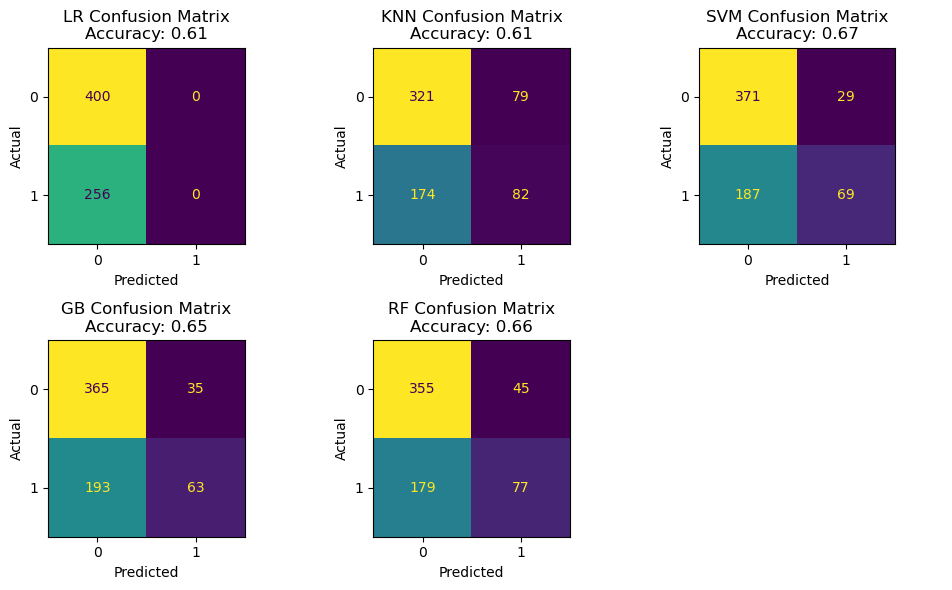

In [62]:
# Create subplot layout
fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()

# Generate confusion matrices for all models
for i, (name, y_pred) in enumerate(model2.items()):
    # Calculate model accuracy
    acc = accuracy_score(y_test, y_pred)
    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[i], colorbar=False)
    # Add titles and labels    
    axes[i].set_title(f"{name} Confusion Matrix\nAccuracy: {acc:.2f}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Hide unused subplot
axes[len(model2)].axis("off")

# Adjust layout and display figure
plt.tight_layout()
plt.show()

The Confusion Matrix structure used in this study is represented as follows:

| Actual Class        | Predicted Non-potable (0) | Predicted Potable (1) |
|---------------------|---------------------------|-----------------------|
| Non-potable (0)     |    [[TN                   |        FP]            |
| Potable (1)         |    [FN                    |       TP]]            |

The Confusion Matrices confirm the patterns previously observed in the Classification Reports and provide a direct visualization of the classification errors made by each model.

- **LR model** predicts all observations as non-potable, resulting in zero true positives (TP) and zero false positive (FP). Although this completely avoids contaminated water being classified as potable, the model **fails to identify any potable water samples** and is therefore unsuitable for practical water potability prediction.<br>
- **KNN model** achieves **the highest number of correctly identified potable water samples (82 TP)**. However, it also generates the highest number of false positives (79 FP), indicating a greater tendency to **incorrectly classify contaminated water as potable**. From a public health perspective, this represents a considerable risk.<br>
- **SVM model** produces **the lowest number of false positives (29 FP)** among the functional models, indicating that potable predictions generated by this model are generally more reliable. Nevertheless, the relatively high number of false negatives (187 FN) shows that **many actual potable water samples remain undetected**.<br>
- **GB model** demonstrates **behaviour similar to RF**, although with slightly fewer correctly detected potable water samples (63 TP) and a lower F1-score (0.36). Its overall performance remains competitive but slightly below RF.<br>
- **RF model**  provides **the most balanced Confusion Matrix overall**. Although it produces more false positives than SVM (45 FP versus 29 FP), it correctly identifies a larger number of potable water samples (77 TP versus 69 TP). This balance between potable water detection and contamination control is consistent with its **superior F1-score performance (0.41 versus 0.39)** observed in the Classification Reports.<br>

Overall, the Confusion Matrix analysis highlights an important trade-off between maximizing potable water detection (TP) and minimizing contamination misclassification errors (FP).<br> 
The evaluated models exhibit different strengths. KNN identifies the largest number of potable water samples but also generates the highest contamination risk. SVM minimizes contamination misclassification errors and therefore provides the most conservative potable predictions. **RF achieves the best balance between potable water detection and contamination control**, while GB demonstrates a performance profile similar to RF but with slightly lower overall effectiveness.<br>
These findings are consistent with the Classification Report results, where **RF achieved the highest F1-score, indicating the most balanced compromise between Precision and Recall**. Consequently, RF remains the most suitable overall model for water potability prediction among the evaluated algorithms.

## 10. Model Evaluation 

Model Evaluation represents an advanced validation stage of the machine learning workflow. While the previous chapter provided an initial comparison of the evaluated models, this stage applies more comprehensive evaluation techniques to assess whether the selected models are robust, reliable and capable of generalising to unseen data.<br>

In this study, the Model Evaluation consists of the following evaluation techniques:
<br>- **ROC Curve and ROC-AUC**, to assess the discrimination capability of each classification model across different decision thresholds using the **test dataset**.
<br>- **Overfitting Assessment**, to compare **training and testing** performance and evaluate model generalisation.
<br>- **Cross-Validation Analysis of the Base Models**, to assess model stability and robustness across multiple data partitions of the baseline models using the **training dataset**.
<br>- **Candidate Model Selection**, to integrate all evaluation metrics and identify the strongest candidate base models for Hyperparameter Tuning.

Overall, this stage provides a **more rigorous validation of the trained models**, confirming whether the initial model selection remains appropriate after applying more advanced evaluation techniques.

### 10.1 ROC Curve and ROC-AUC

Receiver Operating Characteristic Curve (ROC Curve) and Area Under the Receiver Operating Characteristic Curve (ROC-AUC) are widely used evaluation techniques for binary classification models. While Accuracy, Precision, Recall and F1-Socre evaluate model performance using a single decision threshold (typically 0.50), ROC Curve and ROC-AUC **assess model performance across multiple decision thresholds**, providing a more comprehensive evaluation of its ability to distinguish between two classes (potable and non-potable).<br>
The ROC Curve provides a graphical comparison of model performance across different decision thresholds. In general, curves that remain closer to the upper-left corner indicate better classification performance than those closer to the diagonal reference line.<br>
The ROC-AUC summarizes the information contained in the ROC Curve into a single numerical value ranging from 0 to 1. Higher ROC-AUC values indicate better overall classification performance across different decision thresholds, whereas values close to 0.50 suggest that the model has little ability to distinguish between the two classes.<br>
In this section, the ROC Curve and ROC-AUC are used to compare the classification performance of the evaluated models and provide additional evidence for selecting the most appropriate model for water potability prediction.

In [63]:
# Store model predictions
base_model_test = [("Logistic Regression (LR)", lr_model, X_test_scaled), ("K-Nearest Neighbors (KNN)", knn_model, X_test_scaled), 
               ("Support Vector Machine (SVM)", svm_model, X_test_scaled), ("Gradient Boosting (GB)", gb_model, X_test), 
               ("Random Forest (RF)", rf_model, X_test)]  # SVM (need probability=True in the model)

# Store ROC-AUC values
roc_auc_base_table = []

# Calculate ROC-AUC for each model
for name, model, X_data in base_model_test:
    y_prob = model.predict_proba(X_data)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    roc_auc_base_table.append({"Model": name, "ROC-AUC": roc_auc})

# Create ROC-AUC comparison table
roc_auc_base_table = (pd.DataFrame(roc_auc_base_table).sort_values("ROC-AUC", ascending=False))

# Display table
roc_auc_base_table.style.hide(axis="index").format({"ROC-AUC": "{:.3f}"})

Model,ROC-AUC
Support Vector Machine (SVM),0.649
Random Forest (RF),0.641
Gradient Boosting (GB),0.628
K-Nearest Neighbors (KNN),0.598
Logistic Regression (LR),0.548


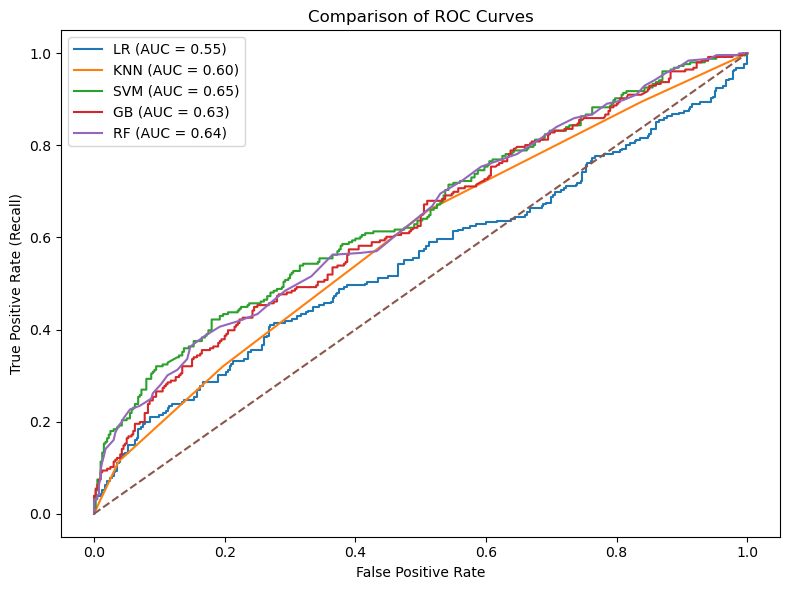

In [64]:
# Store model predictions
base_model_plot = [("LR", lr_model, X_test_scaled), ("KNN", knn_model, X_test_scaled), ("SVM", svm_model, X_test_scaled), 
               ("GB", gb_model, X_test), ("RF", rf_model, X_test)]  

# Create omparison of ROC curves
plt.figure(figsize=(8,6))

# Generate ROC curves for each model
for name, model, X_data in base_model_plot:
    # Predict class probabilities
    y_prob = model.predict_proba(X_data)[:, 1]
    # Calculate ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    # Calculate ROC-AUC    
    roc_auc = roc_auc_score(y_test, y_prob) 
    # Plop ROC Curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot the random baseline
plt.plot([0,1], [0,1], linestyle='--')

# Customize the figure
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Comparison of ROC Curves")
plt.legend()

# Display the figure
plt.tight_layout()
plt.show()

ROC-AUC values are commonly interpreted according to the following ranges:

| ROC-AUC        | Interpretation |
|----------------|----------------|
| 0.50 - 0.60    | Fail / No discrimination |
| 0.60 – 0.70    | Poor discrimination |
| 0.70 – 0.80    | Acceptable discrimination |
| 0.80 - 0.90    | Excellent discrimination |
| 0.90 - 1.00    | Outstanding discrimination |

The ROC curves indicate that **SVM achieves the highest ROC-AUC value**, followed closely by RF and GB. According to the ROC-AUC interpretation table, **all three models fall within the Poor Discrimination range**, although they achieve the highest ROC-AUC values among the evaluated models.<br>
KNN obtains an intermediate ROC-AUC value, while **LR** shows the lowest ROC-AUC value and its ROC Curve remains relatively close to the diagonal reference line, indicating **limited ability to distinguish between potable and non-potable water**.<br>
Unlike Accuracy, Classification Report and Confusion Matrix, the ROC Curve and ROC-AUC evaluate model performance across different classification thresholds. Therefore, they provide a broader evaluation of the classification performance of each model.<br>
Overall, the ROC Curve and ROC-AUC indicate that **SVM provides the best classification performance among the evaluated models**. However, the final model selection should also consider the results of the **Overfitting Assessment, Cross-Validation Analysis and Hyperparameter Tuning**, which are presented in the following sections.

### 10.2 Overfitting Assessment

A key aspect of **Model Evaluation** is determining whether a machine learning model generalises well to unseen data or simply memorizes the training data. **A well-performing model should achieve similar performance on both the training and testing datasets**. Large differences between these results indicate that the model may not generalise well to new observations.<br>
In this study, overfitting is assessed by comparing the training accuracy and testing accuracy of each classification model. The difference between these values (Gap) is also calculated. A small gap indicates good generalisation, whereas a large gap suggests possible overfitting.<br>
This analysis provides additional evidence of model reliability and generalisation before the final model evaluation.<br>

In [65]:
# Store training and testing datasets for each model
base_model_train_test = {"Logistic Regression (LR)": (lr_model, X_train_scaled, X_test_scaled), 
                         "K-Nearest Neighbors (KNN)": (knn_model, X_train_scaled, X_test_scaled), 
                         "Support Vector Machine (SVM)": (svm_model, X_train_scaled, X_test_scaled), 
                         "Gradient Boosting (GB)": (gb_model, X_train, X_test), "Random Forest (RF)": (rf_model, X_train, X_test)}

# Store model performance results 
train_test_base_table = []

# Calculate training and test accuracy and performance gap
for name, (model, X_tr, X_te) in base_model_train_test.items():
    train_acc = model.score(X_tr, y_train)
    test_acc = model.score(X_te, y_test)
    train_test_base_table.append({"Model": name, "Train Accuracy": train_acc, "Test Accuracy": test_acc, "Generalisation Gap": train_acc - test_acc})

# Create comparison table
train_test_base_table = pd.DataFrame(train_test_base_table).sort_values("Generalisation Gap", ascending=True)

# Display comparison table
train_test_base_table.style.hide(axis="index").format({"Train Accuracy": "{:.3f}", "Test Accuracy": "{:.3f}", "Generalisation Gap": "{:.3f}"})

Model,Train Accuracy,Test Accuracy,Generalisation Gap
Logistic Regression (LR),0.610,0.610,0.000
Support Vector Machine (SVM),0.738,0.671,0.067
Gradient Boosting (GB),0.742,0.652,0.090
K-Nearest Neighbors (KNN),0.764,0.614,0.150
Random Forest (RF),1.000,0.659,0.341


Generalisation Gap can be evaluated using the following guidelines:

| Generalisation Gap | Interpretation |
|--------------------|----------------|
| 0.00 – 0.05 | Excellent generalisation |
| 0.05 – 0.10 | Good generalisation |
| 0.10 – 0.20 | Moderate overfitting risk |
| > 0.20 | High overfitting risk |

The Generalisation Gap is calculated as:<br>
**Generalisation Gap = Train Accuracy − Test Accuracy**<br>
A small Generalisation Gap indicates that the model performs similarly on both the training and testing datasets, suggesting good generalisation. A large Generalisation Gap indicates that the model performs much better on the training data than on unseen (test) data, suggesting possible overfitting.

To evaluate the generalisation capacity of the evaluated models, the Generalisation Gap is compared together with the training and testing accuracy results.<br>
**RF** presents the largest Generalisation Gap, **indicating a high risk of overfitting**. Although the model achieves perfect training accuracy, its considerably lower testing accuracy suggests that it memorizes the training data rather than learning patterns that generalise well to unseen data.<br>
**KNN** shows a moderate Generalisation Gap, **indicating mild overfitting**. The difference between training and testing performance suggests that the model learns useful patterns but loses part of its predictive ability when applied to new data.<br>
**GB and SVM** present relatively small Generalisation Gaps, **indicating good generalisation and stable performance**. Their training and testing accuracies remain reasonably close, suggesting that both models learn patterns that generalise well to unseen data.<br>
**LR** presents the smallest Generalisation Gap. However, this should not be interpreted as the best model. The small gap results from similarly low training and testing accuracy, **indicating underfitting rather than strong generalisation**. As shown in the previous evaluation metrics, Logistic Regression fails to identify potable water samples correctly, limiting its practical predictive performance.<br>
Overall, GB and SVM currently provide the best balance between model stability and generalisation, while RF requires further optimisation to reduce overfitting. Therefore, additional evaluation through **Cross-Validation Analysis and Hyperparameter Tuning** is necessary before selecting the final model.

### 10.3 Cross-Validation Analysis of the Base Models

Cross-Validation is a resampling technique used to evaluate how consistently a machine learning model **performs across different subsets of the training data**. Unlike previous evaluation metrics, which rely on a single train-test split, this approach repeatedly **partitions the training data into different folds**, allowing the model to be trained and validated multiple times.<br>
During the Cross-Validation process, one fold is reserved for validation while the **remaining folds are used for training**. This process is repeated until each fold has been used once for validation, producing multiple validation accuracy scores that are averaged to estimate the model’s overall performance.<br>
The **Mean Cross-Validation (CV) Accuracy** represents the expected validation performance of the model across all folds, while the Standard Deviation (Std) measures how much the accuracy varies between these validation results. **A higher Mean CV Accuracy combined with a lower Std indicates that the model** performs more consistently across different data partitions and **is therefore considered more stable and reliable**.

In [66]:
# Store evaluated models
base_model_train = [("Logistic Regression (LR)", lr_model, X_train_scaled), ("K-Nearest Neighbors (KNN)", knn_model, X_train_scaled), 
               ("Support Vector Machine (SVM)", svm_model, X_train_scaled), ("Gradient Boosting (GB)", gb_model, X_train), 
               ("Random Forest (RF)", rf_model, X_train)]  

# Store Cross-Validation results
cv_base_table = []

# Perform 5-fold Cross-Validation for each model
for name, model, X_data in base_model_train:
    # Calculate Cross-Validation Accuracy
    scores = cross_val_score(model, X_data, y_train, cv=5, scoring="accuracy")
    # Store model performance
    cv_base_table.append({"Model": name, "Mean CV Accuracy": scores.mean(), "Std": scores.std()})

# Create comparison table
cv_base_table = (pd.DataFrame(cv_base_table).sort_values("Mean CV Accuracy", ascending=False))

# Display comparison table
cv_base_table.style.hide(axis="index").format({"Mean CV Accuracy": "{:.2f}", "Std": "{:.3f}"})

Model,Mean CV Accuracy,Std
Support Vector Machine (SVM),0.68,0.012
Random Forest (RF),0.67,0.018
Gradient Boosting (GB),0.64,0.010
K-Nearest Neighbors (KNN),0.63,0.022
Logistic Regression (LR),0.61,0.002


The Mean CV Accuracy can be interpreted using the following guidelines:

| Mean CV Accuracy | Interpretation |
|--------------------|----------------|
|   < 0.60    | Weak predictive performance |
| 0.60 – 0.70 | Moderate predictive performance |
| 0.70 – 0.80 | Good predictive performance |
|   > 0.80    | Excellent predictive performance |

For this study, the following Std ranges are used as a practical references to interpret **model stability**:

| Std | Interpretation |
|--------------------|----------------|
|   < 0.02    | Very stable model |
| 0.02 – 0.05 | Acceptable stability |
|   > 0.05    | Low stability (less reliable) |

In this study, **five-fold Cross-Validation (cv = 5)** is applied. The training dataset is divided into five approximately equal subsets (folds), where four folds are used for training and one fold is reserved for validation during each iteration. This process is repeated until every fold has been used once for validation and the validation accuracy obtained in each iteration is averaged to estimate the model's overall perfonrmace.<br>
The Cross-Validation results indicate that **SVM achieves the highest Mean CV Accuracy**, followed by RF and GB. According to the interpretation table, **all evaluated models fall within the Moderate predictive performance range**. 
These results are generally consistent with the previous evaluation metrics. SVM remains the best-performing model, confirming its strong generalisation ability. RF and GB also show competitive performance, although their ranking differs slightly from the Overttind Assessment, suggesting that the model stability may vary depending on the evaluation metric used.<br>
The Std values are very low for all evaluated models, indicating that the validation accuracy remains consistent across the different folds. This suggests that the models are not highly sensitive to the specific partition of the training data and **produce stable and consistent results during repeated validation**.<br>
Overall, Cross-Validation results provides additional evidence that **SVM is the most reliable classifier among the evaluated models**. However, the final model selection should also consider the results obtained after **Hyperparameter Tuning**.

### 10.4 Candidate Model Selection

To identify **the most suitable models for Hyperparameter Tuning**, the evaluation results obtained in the previous sections are integrated into a single comparison table.<br> 
Five complementary performance metrics (Accuracy, F1-score, ROC-AUC, Generalisation Gap and Mean CV Accuracy) are used to rank the models. Train and Test Accuracy are also included to provide additional context regarding each model's generalisation behaviour.<br>
**Each model receives one point whenever it ranks among the top three for a given evaluation metric**. Models with the highest total scores are selected as candidates for further optimisation.

In [67]:
# Merge the evaluation results into a single comparison table
base_model_table = (accuracy_base_table[["Model", "Accuracy"]].
                    merge(classification_base_table[["Model", "F1-score"]], on="Model").
                    merge(roc_auc_base_table[["Model", "ROC-AUC"]], on="Model").
                    merge(train_test_base_table[["Model", "Generalisation Gap"]], on="Model").
                    merge(cv_base_table[["Model", "Mean CV Accuracy"]], on="Model"))

# Initialise score
base_model_table["Score"] = 0

# Calculate a performance score based on the evaluated metrics
# +1 for Top 3 Test Accuracy
base_model_table.loc[base_model_table["Accuracy"].nlargest(3).index, "Score"] += 1
# +1 for Top 3 F1-score
base_model_table.loc[base_model_table["F1-score"].nlargest(3).index, "Score"] += 1
# +1 for Top 3 ROC-AUC
base_model_table.loc[base_model_table["ROC-AUC"].nlargest(3).index, "Score"] += 1
# +1 for Lowest 3 Generalisation Gap
base_model_table.loc[base_model_table["Generalisation Gap"].nsmallest(3).index, "Score"] += 1
# +1 for Top 3 Mean CV Accuracy
base_model_table.loc[base_model_table["Mean CV Accuracy"].nlargest(3).index, "Score"] += 1

# Select the three highest scores
base_model_table["Candidate"] = "No"
base_model_table.loc[base_model_table["Score"].nlargest(3).index, "Candidate"] = "Yes"
base_model_table = (pd.DataFrame(base_model_table).sort_values("Score", ascending=False))

# Display table
base_model_table.style.hide(axis="index").format({"Accuracy": "{:.3f}", "F1-score": "{:.3f}", "ROC-AUC": "{:.3f}", "Generalisation Gap": "{:.3f}", 
                                                  "Mean CV Accuracy": "{:.3f}", })

Model,Accuracy,F1-score,ROC-AUC,Generalisation Gap,Mean CV Accuracy,Score,Candidate
Support Vector Machine (SVM),0.671,0.390,0.649,0.067,0.682,5,Yes
Random Forest (RF),0.659,0.407,0.641,0.341,0.667,4,Yes
Gradient Boosting (GB),0.652,0.356,0.628,0.090,0.638,4,Yes
K-Nearest Neighbors (KNN),0.614,0.393,0.598,0.150,0.629,1,No
Logistic Regression (LR),0.610,0.000,0.548,0.000,0.610,1,No


The integrated evaluation identifies **SVM, GB and RF as the strongest candidates for Hyperparameter Tuning**. These models consistently rank among the top performers across multiple evaluation metrics while maintaining acceptable training and testing performance, indicating a balanced combination of predictive performance, generalisation capability and stability.<br> 
In contrast, **LR and KNN obtain lower overall scores** and are excluded from the optimisation stage.<br>
These **three models are therefore carried forward to the Model Optimisation** chapter. 

## 11. Model Optimisation

Following the identification of the three best-performing candidate models, this chapter focuses on improving their predictive performance through **Hyperparameter Optimisation** while maintaining good generalisation capability. Rather than modifying the learning algorithms themselves, the optimisation process identifies the combination of hyperparameter values that provides the best balance between predictive performance, model robutness and generalisation.<br>
In this study, model optimisation is applied independently to the three selected candidate models: **SVM, GB and RF**. Each optimised model is subsequently compared with its corresponding **Baseline Model** to evaluate the impact of Hyperparameter Tuning on predictice performance and generalisation.

The optimisation process consists of the following stages:
<br> - **Hyperparameter Optimisation**, to identify the optimal hyperparameter values for each candidate model.
<br> - **Optimised Performance**, to compare the predictive performance of the baseline and optimised models using the **test dataset**.
<br> - **Generalisation Assessment**, to evaluate whether the optimised models maintain an appropriate balance between **training and testing** performance.
<br> - **Cross-Validation Analysis of the Optimised Models**, to assess model stability and robustness across multiple data partitions after Hyperparameter Tuning.
<br> - **Final Optimised Model Selection**, to identify the best-performing optimised model based on the combined evaluation metrics.

Overall, this chapter determines whether **Hyperparameter Optimisation** improves the predictive capability of the selected candidate models and identifies the final optimised models for subsequent interpretation.

### 11.1 Hyperparameter Optimisation

This stage focuses on refining each candidate model through **Hyperparameter Tuning**. A predefined **search space** is established for the hyperparameters of each learning algorithm, allowing different hyperparameter combinations to be evaluated systematically. Unlike model parameters, which are learned automatically during training, hyperparameters are specified before training and control how the learning algorithm is configured.<br>
**Grid Search** is then applied to explore every combination within the defined **search space**. This procedure is performed independently for SVM, GB and RF, enabling each model to be tuned according to its own algorithm-specific hyperparameters.

#### 11.1.1 Support Vector Machine (SVM)

In [68]:
# Define hyperparameter search space for SVM
param_grid_svm = {'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1], 'kernel': ['rbf']}

# Initialise SVM classifier
svm = SVC(probability=True, random_state=42)

# Configure Grid Search for Hyperparameter Tuning
grid_svm = GridSearchCV(estimator=svm, param_grid=param_grid_svm, cv=5, scoring='f1', n_jobs=-1) # n_jobs=-1: Uses available CPU coresto speed up Grid Search

# Run Grid Search to identify the optimal hyperparameter configuration
grid_svm.fit(X_train_scaled, y_train)

# Obtain the best model
best_svm = grid_svm.best_estimator_

# Extract optimal hyperparameter configuration
best_params_svm = pd.DataFrame(grid_svm.best_params_.items(), columns=['Hyperparameter', 'Value'])

# Display optimal hyperparameter configuration
best_params_svm.style.hide(axis='index')

Hyperparameter,Value
C,100
gamma,0.100000
kernel,rbf


#### 11.1.2 Gradient Boosting (GB)

In [69]:
# Define hyperparameter search space for GB
param_grid_gb = {'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 4, 5], 'min_samples_leaf': [1, 2],
                 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}

# Initialise GB classifier
gb = GradientBoostingClassifier(random_state=42)

# Configure Grid Search for Hyperparameter Tuning
grid_gb = GridSearchCV(estimator=gb, param_grid=param_grid_gb, cv=5, scoring='f1', n_jobs=-1)

# Run Grid Search to identify the optimal hyperparameter configuration
grid_gb.fit(X_train, y_train)

# Obtain the best model
best_gb = grid_gb.best_estimator_

# Extract optimal hyperparameter configuration
best_params_gb = pd.DataFrame(list(grid_gb.best_params_.items()), columns=['Hyperparameter', 'Value'])

# Display optimal hyperparameter configuration
best_params_gb.style.hide(axis='index').format({'Value': '{:g}'})

Hyperparameter,Value
learning_rate,0.1
max_depth,5
min_samples_leaf,1
min_samples_split,5
n_estimators,200


#### 11.1.3 Random Forest (RF)

In [70]:
# Define hyperparameter search space for RF
param_grid_rf = {'max_depth': [5, 10, 15, None], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, 4], 
                 'min_samples_split': [2, 5, 10], 'n_estimators': [100, 200]}

# Initialise RF classifier
rf = RandomForestClassifier(random_state=42)

# Configure Grid Search for Hyperparameter Tuning
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='f1', n_jobs=-1)

# Run Grid Search to identify the optimal hyperparameter configuration
grid_rf.fit(X_train, y_train)

# Obtain the best model
best_rf = grid_rf.best_estimator_

# Extract optimal hyperparameter configuration
best_params_rf = pd.DataFrame(grid_rf.best_params_.items(), columns=['Hyperparameter', 'Value'])

# Display optimal hyperparameter configuration
best_params_rf.style.hide(axis='index')

Hyperparameter,Value
max_depth,None
max_features,sqrt
min_samples_leaf,2
min_samples_split,2
n_estimators,100


The optimisation process identifies the optimal hyperparameter configuration for each candidate model by evaluating multiple hyperparameter combinations using **Grid Search with five-fold Cross-Validation (cv = 5)**. The F1-score is used as the optimisation criterion and the hyperparameter configuration that achieves **the highest F1-score is selected as the optimal solution for each model**.<br>
The tables above present the optimal hyperparameter configurations identified for SVM, GB and RF. These configurations are subsequently used to train the optimised version of each model, whose predictive performance and generalisation capability are evaluated and compared with the corresponding baseline models in the following section.

### 11.2 Performance Assessment

Performance Assessment evaluates **whether Hyperparameter Tuning improves the predictive performance** of the selected candidate models. The optimised models are evaluated on the **test dataset** using Accuracy, F1-score and ROC-AUC. These results **are directly compare with the corresponding Baseline Models** to assess how Hyperparameter Tuning affects each evaluation metric.<br> 
Presenting these metrics in a single comparison table facilitates identifying the model that **achieves the strongest overall predictive performance after Hyperparameter Tuning**.<br> 
This assessment **focuses on predictive performance**, while the following section evaluates whether the optimised models also generalise effectively to unseen data.

In [71]:
# Predict the test dataset
y_pred_svm_opt = best_svm.predict(X_test_scaled)
y_prob_svm_opt = best_svm.predict_proba(X_test_scaled)[:, 1]

y_pred_gb_opt = best_gb.predict(X_test)
y_prob_gb_opt = best_gb.predict_proba(X_test)[:, 1]

y_pred_rf_opt = best_rf.predict(X_test)
y_prob_rf_opt = best_rf.predict_proba(X_test)[:, 1]


# Create Optimised Performance comparison table
perform_opt_table = pd.DataFrame({"Model": ["Support Vector Machine (SVM)", "Gradient Boosting (GB)", "Random Forest (RF)"], 
                                      "Accuracy": [accuracy_score(y_test, y_pred_svm_opt), accuracy_score(y_test, y_pred_gb_opt), 
                                                   accuracy_score(y_test, y_pred_rf_opt)],
                                      "F1-score": [classification_report( y_test, y_pred_svm_opt, output_dict=True)["1"]["f1-score"], 
                                                   classification_report(y_test, y_pred_gb_opt, output_dict=True)["1"]["f1-score"], 
                                                   classification_report(y_test, y_pred_rf_opt, output_dict=True)["1"]["f1-score"]],
                                      "ROC-AUC": [roc_auc_score(y_test, y_prob_svm_opt), roc_auc_score(y_test, y_prob_gb_opt), 
                                                  roc_auc_score(y_test, y_prob_rf_opt)]})

# Merge Baseline and Optimised Performance tables
perform_table = (base_model_table[["Model", "Accuracy", "F1-score", "ROC-AUC"]].
                 merge(perform_opt_table[["Model", "Accuracy", "F1-score", "ROC-AUC"]], on="Model", suffixes=("_Base", "_Optimised")))

# Sort by Optimised ROC-AUC
perform_table = perform_table.sort_values(by="ROC-AUC_Optimised", ascending=False)

# Create grouped column headers
perform_table.columns = pd.MultiIndex.from_tuples([("", "Model"), ("Baseline Models", "Accuracy"), ("Baseline Models", "F1-score"), 
                                                   ("Baseline Models", "ROC-AUC"), ("Optimised Models", "Accuracy"), 
                                                   ("Optimised Models", "F1-score"), ("Optimised Models", "ROC-AUC")])

# Display table
perform_table.style.hide(axis="index").format({ ("Baseline Models","Accuracy"):"{:.3f}", ("Baseline Models","F1-score"):"{:.3f}", 
                                               ("Baseline Models","ROC-AUC"):"{:.3f}", ("Optimised Models","Accuracy"):"{:.3f}", 
                                               ("Optimised Models","F1-score"):"{:.3f}", ("Optimised Models","ROC-AUC"):"{:.3f}"})

The comparison indicates that **RF achieves the strongest overall predictive performance on the test dataset** among the optimised candidate models after Hyperparameter Tuning. It obtains the highest Accuracy and ROC-AUC, while GB achieves the highest F1-score. **GB provides the second-best overall predictive performance**, whereas **SVM records the lowest predictive performance** across the evaluated metrics.<br>
Compared with the corresponding **Baseline Models**, Hyperparameter Tuning affects the candidate models differently. RF improves all three evaluation metrics (Accuracy, F1-score and ROC-AUC), indicating the greatest overall benefit from optimisation. GB also improves its Accuracy and F1-score while maintaining the same ROC-AUC, demonstrating a moderate performance gain. In contrast, SVM shows a slight reduction in Accuracy and ROC-AUC despite a small improvement in F1-score, suggesting that Hyperparameter Tuning does not necessarily improve every learning algorithm.<br>
Overall, the results show that Hyperparameter Tuning does not affect all candidate models equally. While RF becomes the strongest-performing model in terms of predictive performance after optimisation, the final model selection also considers the results of the **Generalisation Assessment** and **Cross-Validation Analysis** presented in the following sections.

### 11.3 Generalisation Assessment

This section evaluates whether **the optimised candidate models generalise effectively to unseen data** rather than memorising the training dataset. A well-generalising model is expected to achieve similar predictive performance on both the **training and testing datasets**. **Large differences between training and testing performance generally indicate overfitting**, whereas similar performance on both datasets suggests good generalisation. However, consistently **low performance on both the training and testing datasets may indicate underfitting** rather than good generalisation.<br> 
The Generalisation Gap of the optimised model **is directly compared with the corresponding Baseline Models** to assess how Hyperparameter Tuning affects each model's generalisation capability. This comparison helps determine whether improvements in predictive performance are achieved without compromising the ability to generalise to unseen data.

In [72]:
# Calculate training and testing accuracy
train_acc_opt_svm = best_svm.score(X_train_scaled, y_train)
test_acc_opt_svm  = best_svm.score(X_test_scaled, y_test)

train_acc_opt_gb = best_gb.score(X_train, y_train)
test_acc_opt_gb  = best_gb.score(X_test, y_test)

train_acc_opt_rf = best_rf.score(X_train, y_train)
test_acc_opt_rf  = best_rf.score(X_test, y_test)

# Create Optimised Generalisation comparison table
general_opt_table = pd.DataFrame({"Model": ["Support Vector Machine (SVM)", "Gradient Boosting (GB)", "Random Forest (RF)"], 
                                     "Train Accuracy": [train_acc_opt_svm, train_acc_opt_gb, train_acc_opt_rf],
                                     "Test Accuracy": [test_acc_opt_svm, test_acc_opt_gb, test_acc_opt_rf],
                                     "Generalisation Gap": [train_acc_opt_svm - test_acc_opt_svm, train_acc_opt_gb - test_acc_opt_gb, 
                                                       train_acc_opt_rf - test_acc_opt_rf]})

# Merge Baseline and Optimised Generalisation tables
general_table = (train_test_base_table[["Model", "Train Accuracy", "Test Accuracy", "Generalisation Gap"]].
                 merge(general_opt_table[["Model", "Train Accuracy", "Test Accuracy", "Generalisation Gap"]], on="Model", 
                       suffixes=("_Base", "_Optimised")))

# Calculate Gap Improvement
general_table["Gap Improvement"] = (general_table["Generalisation Gap_Base"] - general_table["Generalisation Gap_Optimised"])

# Sort by Optimised Generalisation Gap
general_table = general_table.sort_values(by="Generalisation Gap_Optimised", ascending=True)

# Create grouped column headers
general_table.columns = pd.MultiIndex.from_tuples([("", "Model"), ("Baseline Models", "Train Accuracy"), ("Baseline Models", "Test Accuracy"), 
                                                   ("Baseline Models", "Generalisation Gap"), ("Optimised Models", "Train Accuracy"), 
                                                   ("Optimised Models", "Test Accuracy"), ("Optimised Models", "Generalisation Gap"), 
                                                   ("", "Gap Improvement")])

# Display table
general_table.style.hide(axis="index").format({ ("Baseline Models", "Train Accuracy"): "{:.3f}", ("Baseline Models", "Test Accuracy"): "{:.3f}", 
                                               ("Baseline Models", "Generalisation Gap"): "{:.3f}", ("Optimised Models", "Train Accuracy"): "{:.3f}", 
                                               ("Optimised Models", "Test Accuracy"): "{:.3f}", ("Optimised Models", "Generalisation Gap"): "{:.3f}", 
                                               ("", "Gap Improvement"): "{:+.2f}"})

The Generalisation Gap interpretation guidelines presented in the previous section are reproduced below for reference:

| Generalisation Gap | Interpretation |
|--------------------|----------------|
| 0.00 – 0.05 | Excellent generalisation |
| 0.05 – 0.10 | Good generalisation |
| 0.10 – 0.20 | Moderate overfitting risk |
| > 0.20 | High overfitting risk |

The comparison shows that **GB presents the smallest Optimised Generalisation Gap** among the optimised candidate models. **However, all three optimised models exhibit Generalisation Gap values above the threshold associated with a high risk of overfitting**, indicating that none of them achieves strong generalisation performance after Hyperparameter Tuning. Although GB provides the smallest gap, the difference compared with SVM and RF is relatively small.<br>
Compared with the corresponding **Baseline Models**, Hyperparameter Tuning affects the models differently. **GB and SVM both experience an increase in their Generalisation Gap**, indicating that optimisation improves predictive performance at the expense of a larger difference between training and testing accuracy. **In contrast, RF is the only model whose Generalisation Gap decreases slightly after Hyperparameter Tuning**, although it still retains the largest overall gap among the optimised candidate models.<br>
Overall, the results indicate that **improvements in predictive performance do not necessarily translate into improved generalisation capability**. While GB presents the smallest Generalisation Gap among the optimised models, **RF is the only candidate whose generalisation improves relative to its corresponding Baseline Model**. Therefore, **none of the optimised models can be considered clearly superior based solely on Generalisation Assessment**, and the final model selection should consider predictive performance, generalisation capability and the **Cross-Validation Analysis** presented in the following section.

### 11.4 Cross-Validation Analysis of the Optimised Models

Cross-Validation evaluates the robustness and stability of the optimised candidate models **using the same five-fold validation procedure** described in the previous **Cross-Validation Analysis of the Base Models**. Unlike the previous assessments, which are based on a single train-test split, this analysis **estimates model performance across multiple data partitions of the training data**, providing a more reliable measure of predictive stability.<br> 
The Mean CV Accuracy and Std of the optimised models **are directly compared with those of the corresponding Baseline Models** to evaluate how Hyperparameter Tuning affects model robustness and validation performance.<br> 
Models with consistently **high Mean CV Accuracy and low Std are considered more likely to generalise reliably to unseen data**. This assessment therefore provides additional evidence for selecting the most appropriate optimised model.

In [73]:
# Calculate Cross-Validation Accuracy
cv_acc_opt_svm = cross_val_score(best_svm, X_train_scaled, y_train, cv=5, scoring="accuracy")
cv_acc_opt_gb = cross_val_score(best_gb, X_train, y_train, cv=5, scoring="accuracy")
cv_acc_opt_rf = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="accuracy")

# Create Optimised Cross-Validation comparison table
cv_opt_table = pd.DataFrame({"Model": ["Support Vector Machine (SVM)", "Gradient Boosting (GB)", "Random Forest (RF)"], 
                             "Mean CV Accuracy": [cv_acc_opt_svm.mean(), cv_acc_opt_gb.mean(), cv_acc_opt_rf.mean()], 
                             "Std": [ cv_acc_opt_svm.std(), cv_acc_opt_gb.std(), cv_acc_opt_rf.std()]})

# Merge Baseline and Optimised Cross-Validation tables
cv_table = (cv_base_table[["Model", "Mean CV Accuracy", "Std"]].
            merge(cv_opt_table[["Model", "Mean CV Accuracy", "Std"]], on="Model", suffixes=("_Base", "_Optimised")))

# Sort by Optimised Mean CV Accuracy
cv_table = cv_table.sort_values( by="Mean CV Accuracy_Optimised", ascending=False)

# Create grouped column headers
cv_table.columns = pd.MultiIndex.from_tuples([("", "Model"), ("Baseline Models", "Mean CV Accuracy"), ("Baseline Models", "Std"), 
                                              ("Optimised Models", "Mean CV Accuracy"), ("Optimised Models", "Std")])

# Display table
cv_table.style.hide(axis="index").format({("Baseline Models", "Mean CV Accuracy"): "{:.3f}", ("Baseline Models", "Std"): "{:.3f}", 
                                          ("Optimised Models", "Mean CV Accuracy"): "{:.3f}", ("Optimised Models", "Std"): "{:.3f}"})

The Cross-Validation results indicate that **RF achieves the highest Mean CV Accuracy**, followed by GB and SVM. Although the differences are relatively small, RF presents the strongest validation performance among the optimised candidate models. All three optimised models also exhibit very low Std values, indicating stable and consistent performance across the validation folds.<br>
Compared with the corresponding **Baseline Models**, Hyperparameter Tuning affects the candidate models differently. RF improves from the second-highest Mean CV Accuracy among the Baseline Models to the highest after optimisation, indicating that tuning enhances its validation performance. In contrast, **SVM decreases from the highest Mean CV Accuracy before optimisation to the lowest among the optimised candidate models**, while GB shows a slight improvement in Mean CV Accuracy and maintains a low Std, confirming stable behaviour after tuning.<br>
Overall, the Cross-Validation results provide additional evidence that Hyperparameter Tuning improves the validation performance of RF while maintaining excellent stability. Together with the results from the Performance Assessment and Generalisation Assessment, **Cross-Validation supports RF as the most robust optimised candidate model**. Nevertheless, the final model selection should consider all evaluation metrics collectively rather than relying on a single assessment.

### 11.5 Final Optimised Model Selection

To identify **the final optimised model for potable water classification**, the evaluation results obtained in the previous sections are integrated into a single comparison table. Five complementary evaluation metrics are considered, including Accuracy, F1-score, ROC-AUC, Generalisation Gap and Mean CV Accuracy, providing a balanced assessment of predictive performance, classification quality, generalisation ability and validation stability. **Each model receives one point whenever it achieves the best result for an evaluation metric**. The model with the highest total score is selected as the final optimised model for the subsequent interpretation and environmental analysis.

In [142]:
# Merge the evaluation results into a single comparison table
opt_model_table = (perform_opt_table[["Model", "Accuracy", "F1-score", "ROC-AUC"]].
                   merge(general_opt_table[["Model", "Generalisation Gap"]], on="Model").
                   merge(cv_opt_table[["Model", "Mean CV Accuracy"]], on="Model"))                              
                         
# Initialise score
opt_model_table["Score"] = 0 

# +1 for Top Accuracy
opt_model_table.loc[opt_model_table["Accuracy"].nlargest(1).index, "Score"] += 1
# +1 for Top F1-score
opt_model_table.loc[opt_model_table["F1-score"].nlargest(1).index, "Score"] += 1
# +1 for Top ROC-AUC
opt_model_table.loc[ opt_model_table["ROC-AUC"].nlargest(1).index, "Score"] += 1
# +1 for Lowest Generalisation Gap
opt_model_table.loc[opt_model_table["Generalisation Gap"].nsmallest(1).index, "Score"] += 1
# +1 for Top Mean CV Accuracy
opt_model_table.loc[ opt_model_table["Mean CV Accuracy"].nlargest(1).index, "Score"] += 1

# Select Final Model
opt_model_table["Final Model"] = "No"
best_score = opt_model_table["Score"].max()
opt_model_table.loc[opt_model_table["Score"] == best_score, "Final Model"] = "Yes"

# Sort table
opt_model_table = (opt_model_table.sort_values(by="Score", ascending=False))

# Display table
opt_model_table.style.hide(axis="index").format({"Accuracy": "{:.3f}", "F1-score": "{:.3f}", "ROC-AUC": "{:.3f}", 
                                                 "Generalisation Gap": "{:.3f}", "Mean CV Accuracy": "{:.3f}"})

Model,Accuracy,F1-score,ROC-AUC,Generalisation Gap,Mean CV Accuracy,Score,Final Model
Random Forest (RF),0.666,0.428,0.650,0.333,0.673,3,Yes
Gradient Boosting (GB),0.659,0.434,0.634,0.297,0.652,2,No
Support Vector Machine (SVM),0.588,0.410,0.593,0.318,0.637,0,No


The integrated evaluation of the optimised candidate models indicates that **RF achieves the highest overall performance after Hyperparameter Tuning**, obtaining the best results in **Accuracy, ROC-AUC and Mean CV Accuracy** demonstrating strong predictive performance and consistent validation results.<br> 
Although **GB presents the highest F1-score and the smallest Generalisation Gap**, RF demonstrates stronger overall performance across the remaining evaluation metrics, In contrast, **SVM records the lowest overall score**, indicating that it is the least competitive of the three optimised candidate models.<br>
Furthermore, the comparison also indicates that Hyperparameter Tuning affects the candidate models differently. While **RF benefits from optimisation and improves its predictive capability**, **SVM experiences a reduction in Accuracy and ROC-AUC compared with its baseline performance**, illustrating that Hyperparameter Tuning does not necessarily improve every learning algorithm.<br> 
Overall, the final model selection is based on the combined assessment of predictive performance, classification quality, generalisation capability and validation stability rather than on a single evaluation metric. Based on this comprehensive evaluation, **RF is selected as the final optimised model for potable water classification in this study**.

## 12. Model Interpretation 

Following the selection of the **RF as the final optimised model** in the previous chapter, the next step is to understand how the model generates its predictions. While **Model Evaluation and Model Optimisation** focused on comparing predictive performance, generalisation capability and validation stability across different algorithms, **this chapter focuses on interpreting the internal behaviour of the selected model**.<br>
**Model interpretation** provides greater transparency by explaining how the trained RF model uses the available physicochemical variables to classify water samples. It also connects the model's prediction with stablished water quality principles, making the results easier to interpret from an environmental perspective.

This chapter consists of the following stages:
<br> - **Feature Importance Analysis**, to quantify the contribution of each physicochemical variable to the RF model.
<br> - **Interpretation of Key Variables**, to link the most influential features with established water quality principles.
<br> - **Prediction Example**, to demonstrate how the final optimised RF model classifies new water samples.

Overall, this chapter provides an interpretation of the final model by examining the importance of the physicochemical variables and how their combined patterns influence water potability classification.

### 12.1 Feature Importance Analysis 

Feature Importance Analysis is used to measure **how much each physicochemical variable contributes to the predictions** generated by the final RF model. Rather than evaluating predictive performance, this analysis helps explain **which variables have the greatest influence** on the model’s classification of potable and non-potable water samples.<br>
Feature importance scores are calculated for each input variable and ranked from the highest to the lowest importance. **Variables with higher importance scores have a greater influence** on the model’s predictions and therefore contribute more to the final classification.<br>
This analysis provides an interpretable explanation of the **final trained model** by examining the contribution of each physicochemical variable to its predictions. This facilitates the interpretation of the model by showing the **relative importance of the water quality parameters involved** in the classification process.

In [108]:
# Create a DataFrame containing the feature names and their importance scores
feature_importance_df = pd.DataFrame({"Feature": X_train.columns, "Importance": best_rf.feature_importances_})

# Sort the features from highest to lowest importance
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Displat the feature importance table
feature_importance_df.style.hide(axis="index").format({"Importance": "{:.3f}"})

Feature,Importance
ph,0.132
Sulfate,0.130
Hardness,0.123
Solids,0.116
Chloramines,0.114
Conductivity,0.100
Turbidity,0.096
Trihalomethanes,0.095
Organic_carbon,0.095


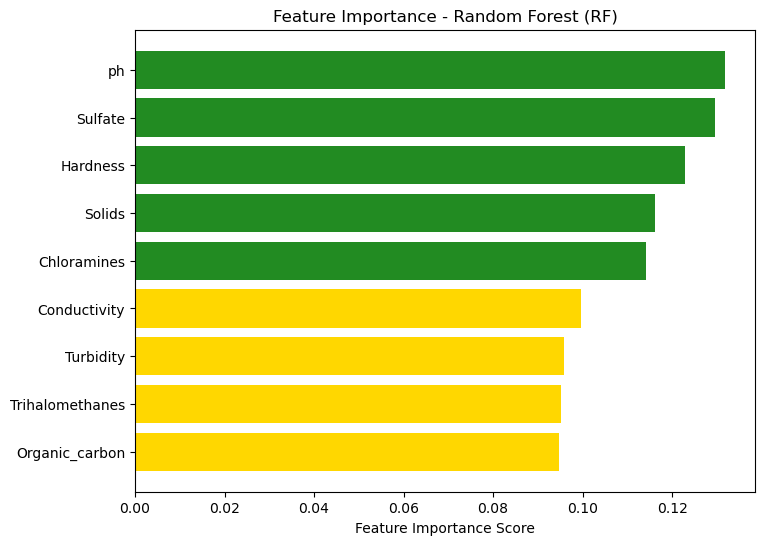

In [216]:
# Create a horizontal bar chart of feature importance
plt.figure(figsize=(8,6))

# Define colours according to feature importance
colors = []

for value in feature_importance_df["Importance"]:
    if value >= 0.10: colors.append("forestgreen")    # High importance
    else: colors.append("gold")                       # Moderate importance

# Create the feature importance plot
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"], color=colors)
plt.xlabel("Feature Importance Score")

# Display the feature importance plot
plt.title("Feature Importance - Random Forest (RF)")
plt.gca().invert_yaxis()
plt.show()

Feature importance scores are relative measures that indicate how much each physicochemical variable contributes to the predictions generated by the final trained RF model. These scores **are always non-negative and are normalised to sum to one**. Therefore, there is no universal treshold for deciding whether a variable should be removed. Instead, the importance scores are interpreted relative to the other variables in the model.<br> Variables with importance scores close to zero generally have little influence on the model. However, they should not automatically removed because their relevance must be interpreted relative to the importance of the remaining variables. When the variables have similar importance scores, they are usually retained because each provides complementary predictive information.<br> 
The Feature Importance Analysis indicates that **pH is the most influential predictor** in the optimised RF model, followed by Sulfate and Chloramines. The relatively small difference between the highest and lowest importance scores is 0.090 (0.162 - 0.072), indicating that the model relies on the combined contribution of multiple physicochemical variables rather than on a single dominant predictor. Therefore, none of the variables exhibits sufficiently low importance to justify removal based solely on feature importance. 

### 12.2 Interpretation of Key Variables

The Feature Importance Analysis identifies **pH, Sulfate, Chloramines, Hardness and Solids (TDS) as the five most influential physicochemical variables** in the final RF model. As described in **Water Quality Parameters**, these variables are recognised indicators of drinking water quality and play different roles in water chemistry and treatment processes. Their high importance scores indicate that the model relies on environmentally meaningful variables that are closely associated with water potability assessment.

- Among all variables, **pH** shows the highest importance score, confirming its strong influence on the model's predictions. This finding is consistent with established drinking water guidelines, as extreme pH values may promote corrosion, scaling and irritation of the eyes, skin and mucous membranes, reducing the suitability of water for human consumption.<br>
- **Sulfate** also shows a high importance score, indicating that sulfate concentration provides valuable information for distinguishing potable from non-potable water samples. Elevated sulfate levels may produce a bitter taste and have laxative effects, reducing drinking water acceptability.<br>
- **Chloramines** are another influential variable in the model. Because chloramines are widely used as disinfectants during water treatment, abnormal concentrations may produce unpleasant taste and odour and may irritate the eyes, skin and mucous membranes, affecting drinking water quality.<br>
- **Hardness** is also identified as an important contributor to the model. High hardness may reduce water acceptability because of scaling in pipes and household appliances, whereas low hardness may promote pipe corrosion, increasing the release of metals into drinking water.
- **Solids (TDS)** also contribute meaningfully to the model’s predictions. Elevated TDS concentrations may affect water taste and indicate increased concentrations of dissolved substances or possible contamination from natural or anthropogenic sources.

Overall, the relatively small differences among the importance scores suggest that the RF model does not rely on a single dominant physicochemical variable. Instead, it combines complementary information from multiple water quality indicators to distinguish potable from non-potable samples. This interpretation is consistent with the environmental principles discussed in **Water Quality Parameters** and supports the inclusion of the complete set of physicochemical variables in the model.<br> 
Although **Turbidity, Organic Carbon and Trihalomethanes** remain environmentally important because they are associated with indirect health risks or long-term water quality concerns, they receive relatively low importance scores in this dataset. This does not imply that these variables are environmentally unimportant; rather, it indicates that, within the available data, **they provide less discriminatory information for distinguishing potable from non-potable water samples** than the five highest-ranked variables.

### 12.3 Prediction Example

To demonstrate the **practical application of the final optimised RF model**, hypothetical water samples are evaluated using selected physicochemical values. The analysis **includes two individual prediction examples**, followed by a **comparative analysis of multiple hypothetical samples** with different combinations of physicochemical parameters. The selected variables correspond to the nine physicochemical parameters used to train the model, with particular attention given to those identified as the most influential variables in the Feature Importance Analysis **(pH, Sulfate, Chloramines, Hardness and Solids)**.<br> 
These examples illustrate how the trained model classifies previously unseen samples and how its prediction function can be applied to hypothetical water quality assessment scenarios.

#### 12.3.1 Prediction Function

This section defines a prediction function that receives the nine physicochemical parameters used to train the final RF model. The function organises the input values into the required format and applies the previously trained model to **generate a water-quality classification as either Potable or Non-Potable**. 

In [182]:
# Create a prediction function for the final trained RF model
def predict_water_quality(pH, Hardness, Solids, Chloramines, Sulfate, Conductivity, Organic_carbon, Trihalomethanes, Turbidity):
    # Create a DataFrame containing the input physicochemical parameters
    sample = pd.DataFrame({"ph": [pH], "Hardness": [Hardness], "Solids": [Solids], "Chloramines": [Chloramines], "Sulfate": [Sulfate], 
                           "Conductivity": [Conductivity], "Organic_carbon": [Organic_carbon], "Trihalomethanes": [Trihalomethanes], 
                           "Turbidity": [Turbidity]})
    # Generate the water potability prediction
    prediction = best_rf.predict(sample)[0]
    # Display the classification result
    if prediction == 1:
        return HTML("""<div style="border:2px solid #2E8B57; border-radius:8px; padding:15px; background-color:#F8FFF8; width:420px; "><div style="font-size:18px; 
        font-weight:bold; margin-bottom:8px; ">Prediction Result</div><hr style="margin-top:0; margin-bottom:12px; "><p style="font-size:16px;
        margin:0; ">Water Quality: <span style="color:#2E8B57; font-weight:bold; ">Potable</span></p></div>""")

    else:
        return HTML("""<div style="border:2px solid #C0392B; border-radius:8px;padding:15px; background-color:#FFF8F8; width:420px; 
        "><div style="font-size:18px; font-weight:bold; margin-bottom:8px; ">Prediction Result</div><hr style="margin-top:0; margin-bottom:12px; 
        "><p style="font-size:16px;margin:0;">Water Quality: <span style="color:#C0392B;font-weight:bold; ">Non-Potable</span></p></div>""")

At this stage, **the function is defined at this stage but is not yet executed** with specific input values. The prediction function is subsequently applied to hypothetical water samples to demonstrate how the final model responds to different combinations of physicochemical parameters.

#### 12.3.2 Individual Prediction Examples

To demonstrate the use of the prediction function, **two hypothetical water samples with different combinations of physicochemical parameters are evaluated**. The samples are designed to represent contrasting water-quality conditions and to illustrate how the final RF model classifies previously unseen samples.

In [208]:
# Define a hypothetical water sample with selected physicochemical values 
predict_water_quality(pH=7.5, Hardness=170, Solids=700, Chloramines=3, Sulfate=200, Conductivity=350, Organic_carbon=1, 
                      Trihalomethanes=50, Turbidity=1)

In [215]:
# Define a hypothetical water sample with selected physicochemical values 
predict_water_quality(pH=9, Hardness=100, Solids=400, Chloramines=5, Sulfate=800, Conductivity=950, Organic_carbon=6, 
                      Trihalomethanes=250, Turbidity=6)

For the first sample, **most of the physicochemical parameters fall within the recommended ranges presented in Water Quality Parameters**, with Hardness and Solids beibg the main exceptions. Both parameters are also among the variables identified as relatively important in the Feature Importance analysis. Despite these values, the RF model classifies the sample as Potable. This result indicates that the prediction is based on the combined pattern of the input variables rather than on individual guideline values.<br>
For the second sample, **most of the physicochemical parameters fall outside the recommended ranges**, while Hardness and Solids remain within the recommended values. In this case, the RF model classifies the sample as Non-Potable, which is consistent with the overall combination of the input parameters.<br>
Overall, the two examples highlight that the **RF model considers the combined information provided by the nine physicochemical parameters** rather than interpreting each parameter independently. The predictions therefore reflect patterns learned from the training dataset rather than a direct application of individual regulatory thresholds.

#### 12.3.3 Comparative Prediction Analysis

This section evaluates multiple hypothetical water samples using different combinations of the nine physicochemical parameters. The purpose is to examine how the final RF model responds to changes in the input variables and to compare the resulting water-quality classifications across different samples.

In [228]:
# Candidate representative samples
candidate_samples = pd.DataFrame({"ph": [6.5, 7.0, 7.2, 7.5, 8.0, 6.8, 7.1, 7.6, 8.2, 6.2], 
                                  "Hardness": [100, 120, 150, 180, 200, 130, 160, 220, 250, 90], 
                                  "Solids": [300, 400, 9000, 600, 700, 350, 100, 550, 800, 250], 
                                  "Chloramines": [2.5, 3.0, 3.5, 4.0, 4.5, 2.8, 3.2, 3.8, 5.0, 2.2], 
                                  "Sulfate": [100, 150, 200, 250, 300, 120, 180, 230, 350, 90], 
                                  "Conductivity": [300, 350, 400, 450, 500, 320, 380, 430, 550, 280], 
                                  "Organic_carbon": [5, 7, 9, 11, 13, 6, 8, 10, 15, 4], 
                                  "Trihalomethanes": [50, 60, 70, 80, 90, 55, 65, 75, 100, 45], 
                                  "Turbidity": [1.5, 2.0, 2.5, 3.0, 3.5, 1.8, 2.2, 2.8, 4.5, 1.2]})

# Generate predictions
predictions = best_rf.predict(candidate_samples)

# Convert predictions into readable labels
candidate_samples["Prediction"] = np.where(predictions == 1, "Potable", "Non-Potable")

# Order predictions: Potable first, followed by Non-Potable
candidate_samples["Prediction"] = pd.Categorical(candidate_samples["Prediction"], categories=["Potable", "Non-Potable"], ordered=True)
candidate_samples = candidate_samples.sort_values("Prediction").reset_index(drop=True)

# Start the displayed index at 1
candidate_samples.index += 1

# Display the table without the index
candidate_samples.style.format({"ph": "{:.2f}", "Chloramines": "{:.2f}", "Turbidity": "{:.2f}"})

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Prediction
1,7.50,180,600,4.00,250,450,11,80,3.00,Potable
2,6.80,130,350,2.80,120,320,6,55,1.80,Potable
3,7.60,220,550,3.80,230,430,10,75,2.80,Potable
4,8.20,250,800,5.00,350,550,15,100,4.50,Potable
5,6.20,90,250,2.20,90,280,4,45,1.20,Potable
6,6.50,100,300,2.50,100,300,5,50,1.50,Non-Potable
7,7.00,120,400,3.00,150,350,7,60,2.00,Non-Potable
8,7.20,150,9000,3.50,200,400,9,70,2.50,Non-Potable
9,8.00,200,700,4.50,300,500,13,90,3.50,Non-Potable
10,7.10,160,100,3.20,180,380,8,65,2.20,Non-Potable


The comparative analysis shows that **the predicted classifications are not determined by a single physicochemical parameter**. Among the Potable samples, several parameters exceed the recommended ranges, particularly Hardness, Solids, Organic_carbon and Turbidity. Sample 4 presents relatively high values across several parameters, including Hardness, Solids, Chloramines, Sulfate, Conductivity, Organic carbon, Trihalomethanes and Turbidity, yet the model classifies the sample as Potable.<br>
In contrast, the Non-Potable samples show combinations of physicochemical parameters with values both within and outside the guideline ranges. For example, sample 8 presents high values for Solids, Organic_carbon and Turbidity and is classified as Non-Potable.<br> 
Overall, these examples show that the RF model evaluates the combined pattern of the nine physicochemical variables rather than applying each guideline value as an independent classification rule. Therefore, **exceeding an individual guideline does not automatically result in a Non-Potable prediction**, while values within **several individual guideline ranges do not necessarily result in a Potable prediction**.

## 13. Conclusions

### 13.1 Overall Model Performance

This study evaluated several machine learning models for the classification of water samples as Potable or Non-Potable based on nine physicochemical parameters. After model comparison, optimization and generalization assessment, Gradient Boosting was selected as the final model based on the overall balance between classification performance and generalization.

However, the obtained performance indicates that the model still has limitations in accurately distinguishing potable and non-potable samples. Therefore, the model should be considered a predictive screening tool rather than a definitive method for determining drinking-water safety.

### 13.2) Model Reliability and Generalisation

The comparison between training, validation and testing results indicates that the final model is able to generalize to previously unseen data without showing extreme overfitting. However, the moderate predictive performance suggests that model optimization alone is not sufficient to substantially improve classifiction accuracy. The characteristics and limitations of the dataset therefore remain an important factor affecting model performance.

### 13.3) Environmental Interpretation

From an environmental perspective, the feature importance analysis shows that the physicochemical variables do not contribute equally to the classification. Parameters such as pH, Sulfate, Chloramines and Hardness were among the most influential variables identified by the model. This highlights the importance of understanding the environmental meaning of the input variables when interpreting machine learning predictions.

The comparative prediction analysis also shows that model predictions do not necessarily coincide directly with individual drinking-water guideline ranges. This is because the model learns relationships and combinations of variables from the training dataset rather than applying regulatory limits as independent decision rules. Therefore, a prediction of Potable should not be interpreted as evidence that all parameters comply with drinking-water standards.

This also demonstrates that environmental knowledge is essential when developing and interpreting machine learning models for water-quality assessment. The statistical prediction must be interpreted together with the environmental significance of the measured parameters and the applicable water-quality guidelines.

### 13.4) Practical Applicability, Limitations and Future Improvements

The final model demonstrates the potential of machine learning as a decision-support tool for the preliminary assessment of water quality. However, its predictions should not replace laboratory analysis or regulatory assessment. The model is limited by the size, structure and variables available in the training dataset.

Future improvements should therefore focus primarily on increasing the size and representativeness of the dataset and incorporating additional water-quality variables. Depending on the intended application, these could include microbiological indicators such as Escherichia coli, nutrients such as nitrate and nitrite, metals and other chemical parameters relevant to drinking-water quality. Including samples from a specific geographical region could also improve the representation of local water-quality conditions.

Further improvements could also involve feature engineering, alternative ensemble methods and additional model optimization. More complex approaches, such as neural networks, could be investigated in future work, although their suitability would depend on the availability of a sufficiently large and representative dataset.

Overall, the results demonstrate that machine learning can support environmental water-quality assessment, but its reliability depends strongly on the quality, representativeness and environmental relevance of the data used for model development.


### 13.5) Final Reflection

#### This project demonstrates that:
- Machine learning can support environmental risk assessment.
- Predictive modelling enhances early detection capacity.
- Balanced evaluation (accuracy, recall, AUC, generalisation) is essential for responsible model selection.
#### While performance is moderate, the structured workflow ensures transparency, interpretability, and scientific rigor.
#### Future improvements could include:
- Larger datasets
- Feature engineering
- Advanced ensemble techniques
- Cross-validation refinementalidation refinement

